CELL 1: MOUNT GOOGLE DRIVE

In [52]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
from google.colab import drive
import os

drive.mount('/content/drive')

print("✅ Google Drive mounted!")
print("\n📁 Expected directory structure:")
print("   /content/drive/MyDrive/ALU_Course_Documents/Diana_Ruzindana/MissionCapstone/Data/dataset")
print("      ├── dataset/")
print("      │   └── Train/")
print("      │       ├── Healthy/")
print("      │       ├── Powdery/")
print("      │       └── Rust/")
print("      ├── Rwanda_Crop_calendar_Data.csv")
print("      └── outputs/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!

📁 Expected directory structure:
   /content/drive/MyDrive/ALU_Course_Documents/Diana_Ruzindana/MissionCapstone/Data/dataset
      ├── dataset/
      │   └── Train/
      │       ├── Healthy/
      │       ├── Powdery/
      │       └── Rust/
      ├── Rwanda_Crop_calendar_Data.csv
      └── outputs/


CELL 2: IMPORT LIBRARIES & ENVIRONMENT CHECK


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import json
import warnings
from datetime import datetime
from pathlib import Path

warnings.filterwarnings('ignore')

# Image / preprocessing
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, InceptionV3
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Reproducibility
plt.style.use('default')
sns.set_palette("husl")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 80)
print("ENVIRONMENT SETUP".center(80))
print("=" * 80)
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("\n⚠️  No GPU detected — Enable in: Runtime → Change runtime type → GPU")
print("=" * 80)

                               ENVIRONMENT SETUP                                
TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.2.2

 GPU Available: 1 device(s)


CELL 3: CONFIGURATION PARAMETERS


In [55]:
COLAB_ROOT = '/content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data'
LOCAL_ROOT = '.'

# Auto-detect environment
if os.path.exists(COLAB_ROOT):
    BASE_ROOT = COLAB_ROOT
    BASE_DIR  = f'{BASE_ROOT}/dataset/Train'
else:
    BASE_ROOT = LOCAL_ROOT
    BASE_DIR  = f'{BASE_ROOT}/dataset/Train'

CROP_CALENDAR_CSV = f'{BASE_ROOT}/Rwanda_Crop_calendar_Data.csv'
OUTPUT_DIR        = f'{BASE_ROOT}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASSES      = ['Healthy', 'Powdery', 'Rust']
IMG_HEIGHT   = 224
IMG_WIDTH    = 224
IMG_SIZE     = (IMG_HEIGHT, IMG_WIDTH)
IMG_CHANNELS = 3
BATCH_SIZE   = 32

CNN_EPOCHS       = 80
INITIAL_EPOCHS   = 35
FINE_TUNE_EPOCHS = 25
TOTAL_EPOCHS     = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

INITIAL_LR   = 1e-3
FINE_TUNE_LR = 5e-5
FINE_TUNE_AT = 100

DROPOUT_1 = 0.3
DENSE_1   = 256
DROPOUT_2 = 0.4
DENSE_2   = 128
DROPOUT_3 = 0.2

TEST_SIZE = 0.15
VAL_SIZE  = 0.15

EARLY_STOP_PATIENCE = 12
REDUCE_LR_PATIENCE  = 4
REDUCE_LR_FACTOR    = 0.4
MIN_LR              = 1e-8

FINAL_MODEL_PATH = f'{OUTPUT_DIR}/cropsense_final_model.keras'
TFLITE_PATH      = f'{OUTPUT_DIR}/cropsense_model.tflite'
TFLITE_F16_PATH  = f'{OUTPUT_DIR}/cropsense_model_f16.tflite'
TFLITE_INT8_PATH = f'{OUTPUT_DIR}/cropsense_model_int8.tflite'

ACCURACY_TARGET = 0.85
ACCURACY_FLOOR  = 0.80

print("=" * 80)
print("CONFIGURATION".center(80))
print("=" * 80)
print(f"\n Dataset      : {BASE_DIR}")
print(f" Crop Calendar: {CROP_CALENDAR_CSV}")
print(f" Output       : {OUTPUT_DIR}")
print(f"\n  Image size   : {IMG_HEIGHT}×{IMG_WIDTH}  (224×224 for MobileNetV2/ResNet50)")
print(f" Batch size   : {BATCH_SIZE}")
print(f"\n Accuracy target : {ACCURACY_TARGET*100:.0f}%  (floor: {ACCURACY_FLOOR*100:.0f}%)")
print(f"🔧 Phase 1 LR    : {INITIAL_LR}  (frozen base, {INITIAL_EPOCHS} epochs)")
print(f"🔧 Phase 2 LR    : {FINE_TUNE_LR}  (fine-tune from layer {FINE_TUNE_AT}, {FINE_TUNE_EPOCHS} epochs)")
print(f"\n🔍 Path check:")
print(f"   CSV     : {'✅' if os.path.exists(CROP_CALENDAR_CSV) else '❌ (will use defaults)'}")
print(f"   Dataset : {'✅' if os.path.exists(BASE_DIR) else '❌ CHECK BASE_DIR'}")
print("=" * 80)

                                 CONFIGURATION                                  

 Dataset      : /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/dataset/Train
 Crop Calendar: /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/Rwanda_Crop_calendar_Data.csv
 Output       : /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs

  Image size   : 224×224  (224×224 for MobileNetV2/ResNet50)
 Batch size   : 32

 Accuracy target : 85%  (floor: 80%)
🔧 Phase 1 LR    : 0.001  (frozen base, 35 epochs)
🔧 Phase 2 LR    : 5e-05  (fine-tune from layer 100, 25 epochs)

🔍 Path check:
   CSV     : ✅
   Dataset : ✅


 Cell 4: LOAD RWANDA CROP CALENDAR


In [56]:
print("=" * 80)
print("LOADING RWANDA CROP CALENDAR".center(80))
print("=" * 80)

try:
    crop_calendar = pd.read_csv(CROP_CALENDAR_CSV)
    print(f"\n✅ Loaded {len(crop_calendar)} rows")
    print(f"Columns: {list(crop_calendar.columns)}")
    print(crop_calendar.head())
    crop_calendar.to_csv(f'{OUTPUT_DIR}/loaded_crop_calendar.csv', index=False)
except FileNotFoundError:
    print(f"\n⚠️  File not found: {CROP_CALENDAR_CSV}")
    print("   Continuing without crop calendar — expert system will use defaults.")
    crop_calendar = None

print("=" * 80)

                          LOADING RWANDA CROP CALENDAR                          

✅ Loaded 97 rows
Columns: ['Crop', 'AgroEcological Zone', 'Additional information', 'Early Sowing', 'Unnamed: 4', 'Later Sowing', 'Unnamed: 6', 'All year', 'Sowing rate', 'Unnamed: 9', 'Growing period', 'Unnamed: 11', 'Early harvest', 'Unnamed: 13', 'Late harvest', 'Unnamed: 15', 'AgroEcological Zone Description', 'AgroEcological Zone Practices', 'AgroEcological Zone Units', 'Comments En', 'Comments ES', 'Comments FR', 'Comments ZH', 'Comments AR', 'Comments RU']
                     Crop AgroEcological Zone  \
0                     NaN                 NaN   
1  Beans, harvested green                Imbo   
2                 Cassava                Imbo   
3                Pea, dry                Imbo   
4                    Corn                Imbo   

                              Additional information Early Sowing Unnamed: 4  \
0                                                NaN          Day      Mont

CELL 5: LOAD & CLEAN IMAGE DATASET


In [57]:
print("=" * 80)
print("LOADING DATASET".center(80))
print("=" * 80)


def remove_corrupted_images(directory):
    """Scan and remove unreadable images."""
    removed = 0
    for root, _, files in os.walk(directory):
        for fname in files:
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            fpath = os.path.join(root, fname)
            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                os.remove(fpath)
                removed += 1
                print(f"   🗑️  Removed corrupted: {fpath}")
    print(f"   Corrupted files removed: {removed}")


def load_images(directory, classes, img_size):
    """Load all images into memory as float32 arrays normalised to [0,1]."""
    X, y = [], []
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            print(f"   ⚠️  Class directory not found: {cls_path}")
            continue
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f"   {cls:12s} → {len(files)} images")
        for fname in files:
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath).convert('RGB').resize(img_size)
                X.append(np.array(img, dtype=np.float32) / 255.0)
                y.append(cls)
            except Exception as e:
                print(f"   ⚠️  Skipping {fname}: {e}")
    return np.array(X), np.array(y)


print("\n🧹 Checking for corrupted images …")
remove_corrupted_images(BASE_DIR)

print("\n📥 Loading images …")
X_all, y_all = load_images(BASE_DIR, CLASSES, IMG_SIZE)

print(f"\n✅ Total loaded : {len(X_all)} images")
print(f"   Shape        : {X_all.shape}")
print(f"   Labels       : {np.unique(y_all, return_counts=True)}")
print("=" * 80)

                                LOADING DATASET                                 

🧹 Checking for corrupted images …
   Corrupted files removed: 0

📥 Loading images …
   Healthy      → 458 images
   Powdery      → 430 images
   Rust         → 434 images

✅ Total loaded : 1322 images
   Shape        : (1322, 224, 224, 3)
   Labels       : (array(['Healthy', 'Powdery', 'Rust'], dtype='<U7'), array([458, 430, 434]))


CELL 6: PREPROCESSING & DATA SPLITTING

In [58]:
print("=" * 80)
print("PREPROCESSING & SPLITTING".center(80))
print("=" * 80)

# Encode labels
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y_all)
num_classes   = len(label_encoder.classes_)
Y_all_cat     = to_categorical(y_encoded, num_classes)

print(f"Classes : {list(label_encoder.classes_)}")
print(f"Num classes: {num_classes}")

# Train / test split
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X_all, Y_all_cat,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded
)

# Train / validation split
y_train_idx = np.argmax(Y_train_full, axis=1)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_train_idx
)

print(f"\n📊 Split summary:")
print(f"   Train : {len(X_train):5d} samples")
print(f"   Val   : {len(X_val):5d} samples")
print(f"   Test  : {len(X_test):5d} samples")

# Class weights (handles class imbalance)
y_train_labels = np.argmax(Y_train, axis=1)
cw_values = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weights = dict(enumerate(cw_values))
print(f"\n⚖️  Class weights: {class_weights}")
print("=" * 80)

                           PREPROCESSING & SPLITTING                            
Classes : [np.str_('Healthy'), np.str_('Powdery'), np.str_('Rust')]
Num classes: 3

📊 Split summary:
   Train :   954 samples
   Val   :   169 samples
   Test  :   199 samples

⚖️  Class weights: {0: np.float64(0.9636363636363636), 1: np.float64(1.0258064516129033), 2: np.float64(1.0127388535031847)}


CELL 7: CLASS DISTRIBUTION VISUALIZATION


                               CLASS DISTRIBUTION                               


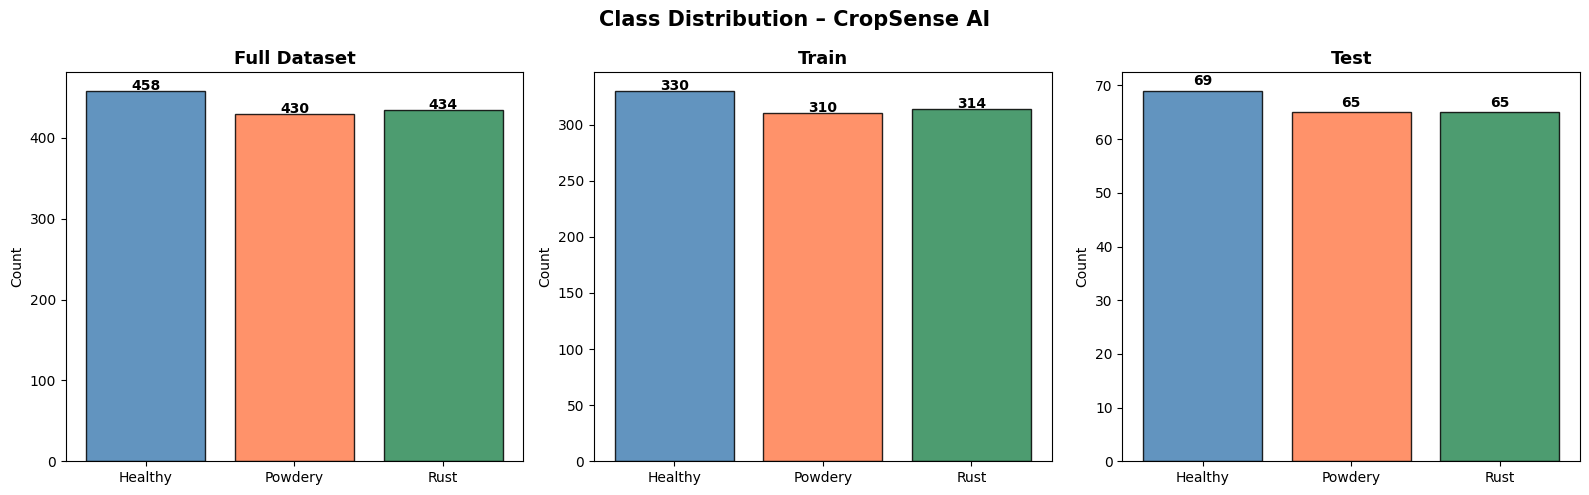

In [59]:
print("=" * 80)
print("CLASS DISTRIBUTION".center(80))
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits = [
    ('Full Dataset', y_all),
    ('Train',        label_encoder.inverse_transform(np.argmax(Y_train, axis=1))),
    ('Test',         label_encoder.inverse_transform(np.argmax(Y_test,  axis=1))),
]

for ax, (title, labels) in zip(axes, splits):
    unique, counts = np.unique(labels, return_counts=True)
    bars = ax.bar(unique, counts, color=['steelblue', 'coral', 'seagreen'],
                  edgecolor='black', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(count), ha='center', fontweight='bold')

plt.suptitle('Class Distribution – CropSense AI', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("=" * 80)

Cell 8: SAMPLE IMAGES VISUALIZATION


                                 SAMPLE IMAGES                                  


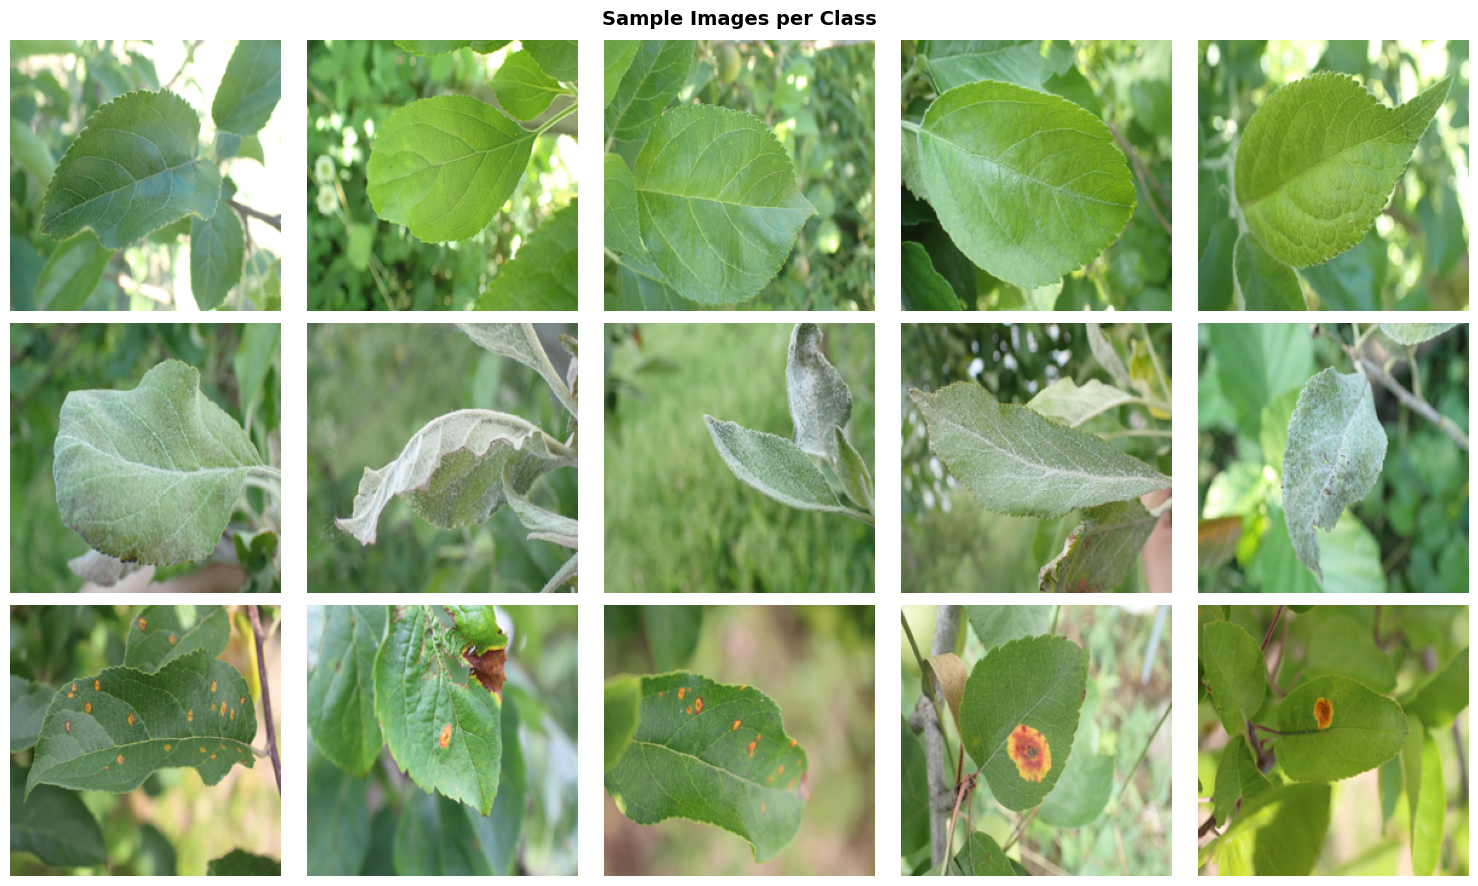

In [60]:
print("=" * 80)
print("SAMPLE IMAGES".center(80))
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, cls in enumerate(label_encoder.classes_):
    cls_mask = (y_all == cls)
    cls_imgs = X_all[cls_mask][:5]
    for col, img in enumerate(cls_imgs):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12, fontweight='bold')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()
print("=" * 80)

CELL 9: DATA AUGMENTATION SETUP


In [61]:
print("=" * 80)
print("DATA AUGMENTATION".center(80))
print("=" * 80)

# Standard augmentation for validation / test (rescale only)
val_datagen = ImageDataGenerator()          # already normalised

# Standard augmentation for transfer learning models
standard_train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.65, 1.35],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

# Heavier augmentation for CNN (needs more variety to generalise)
heavy_train_datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.30,
    height_shift_range=0.30,
    shear_range=0.20,
    zoom_range=0.30,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.6, 1.4],
    channel_shift_range=25.0,
    fill_mode='nearest'
)

# Generator helpers
def make_train_gen(datagen, X, Y, batch_size=BATCH_SIZE):
    return datagen.flow(X, Y, batch_size=batch_size, shuffle=True, seed=SEED)

val_generator = val_datagen.flow(X_val, Y_val, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Augmentation pipelines ready.")
print(f"   Standard  : rotation±30°, shift±25%, zoom±20%, brightness 0.7-1.3")
print(f"   Heavy CNN : rotation±40°, shift±30%, zoom±30%, brightness 0.6-1.4")
print("=" * 80)

                               DATA AUGMENTATION                                
✅ Augmentation pipelines ready.
   Standard  : rotation±30°, shift±25%, zoom±20%, brightness 0.7-1.3
   Heavy CNN : rotation±40°, shift±30%, zoom±30%, brightness 0.6-1.4


 CELL 10: MODEL BUILDER FUNCTIONS

In [62]:
print("=" * 80)
print("MODEL BUILDER".center(80))
print("=" * 80)


def build_model(base_name, num_classes, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    """
    Build a model for training.

    Parameters
    ----------
    base_name   : 'CNN' | 'MobileNetV2' | 'VGG16' | 'ResNet50' | 'InceptionV3'
    num_classes : int
    input_shape : tuple

    Returns
    -------
    model      : tf.keras.Model
    base_model : tf.keras.Model | None  (None for CNN)
    """
    print(f"\n🏗️  Building {base_name} …")

    if base_name == 'CNN':
        # ── 5-block CNN with L2 regularization ───────────────
        inputs = keras.Input(shape=input_shape, name='input_layer')
        REG = tf.keras.regularizers.l2(1e-4)

        for filters, drop in [(32, 0.20), (64, 0.20), (128, 0.25),
                               (256, 0.30), (512, 0.35)]:
            x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same',
                              kernel_regularizer=REG)(inputs if filters == 32 else x)
            x = layers.BatchNormalization()(x)
            x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same',
                              kernel_regularizer=REG)(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling2D((2, 2))(x)
            x = layers.Dropout(drop)(x)

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu', kernel_regularizer=REG)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu', kernel_regularizer=REG)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

        model = keras.Model(inputs=inputs, outputs=outputs, name='CropSense_CNN')
        base  = None
        print(f"   ✓ Architecture : 5 conv blocks (32→64→128→256→512) + L2 regularization")

    else:
        # Transfer-learning head
        base_kwargs = dict(input_shape=input_shape, include_top=False,
                           weights='imagenet', pooling='avg')
        base_map = {
            'MobileNetV2': MobileNetV2,
            'VGG16':       VGG16,
            'ResNet50':    ResNet50,
            'InceptionV3': InceptionV3,
        }
        if base_name not in base_map:
            raise ValueError(f"Unknown base: {base_name}")

        base = base_map[base_name](**base_kwargs)
        base.trainable = False          # frozen in Phase 1

        inputs = keras.Input(shape=input_shape, name='input_layer')
        x      = base(inputs, training=False)
        x      = layers.Dropout(DROPOUT_1)(x)
        x      = layers.Dense(DENSE_1, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x      = layers.BatchNormalization()(x)
        x      = layers.Dropout(DROPOUT_2)(x)
        x      = layers.Dense(DENSE_2, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x      = layers.BatchNormalization()(x)
        x      = layers.Dropout(DROPOUT_3)(x)
        outputs = layers.Dense(
            num_classes, activation='softmax', name='predictions',
            kernel_regularizer=tf.keras.regularizers.l2(5e-4)
        )(x)

        model = keras.Model(inputs=inputs, outputs=outputs,
                            name=f'CropSense_{base_name}')
        print(f"   ✓ Base : {base_name} (frozen for Phase 1)")
        print(f"   ✓ Head : Dense({DENSE_1})→BN→Drop({DROPOUT_2})→Dense({DENSE_2})→BN→Drop({DROPOUT_3})")

    print(f"   ✓ Parameters : {model.count_params():,}")
    return model, base


def make_callbacks(model_name):
    """Return training callbacks and checkpoint path."""
    ckpt_path = f'{OUTPUT_DIR}/best_{model_name}.keras'
    cbs = [
        ModelCheckpoint(filepath=ckpt_path, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=REDUCE_LR_FACTOR,
                          patience=REDUCE_LR_PATIENCE, min_lr=MIN_LR, verbose=1),
    ]
    return cbs, ckpt_path


def compile_model(model, lr=INITIAL_LR):
    """Compile with Adam, label-smoothed cross-entropy and key metrics."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
        ]
    )


def record_results(model_results, model_name, model, ckpt_path, X_test, Y_test):
    """Load best checkpoint, evaluate, and store results dict."""
    best = keras.models.load_model(ckpt_path)
    res  = best.evaluate(X_test, Y_test, verbose=0)
    p, r = res[2], res[3]
    model_results[model_name] = {
        'accuracy' : res[1],
        'precision': p,
        'recall'   : r,
        'f1'       : 2 * p * r / (p + r + 1e-7),
        'auc'      : res[4],
        'params'   : model.count_params(),
    }
    acc = model_results[model_name]['accuracy']
    print(f"\n📊 {model_name} — Test Results")
    print(f"   Accuracy  : {acc*100:.2f}%  {'✅ TARGET MET' if acc >= ACCURACY_TARGET else '⚠️  below target'}")
    print(f"   Precision : {p:.4f}")
    print(f"   Recall    : {r:.4f}")
    print(f"   F1-Score  : {model_results[model_name]['f1']:.4f}")
    print(f"   AUC       : {res[4]:.4f}")
    return best


# Shared results dict
model_results = {}

print("\n✅ Builder functions ready. Models available:")
print("   CNN · MobileNetV2 · VGG16 · ResNet50 · InceptionV3")
print("=" * 80)

                                 MODEL BUILDER                                  

✅ Builder functions ready. Models available:
   CNN · MobileNetV2 · VGG16 · ResNet50 · InceptionV3


CELL 11: TRAIN CNN (BASELINE)


In [63]:
print("=" * 80)
print("TRAINING: CNN (Baseline)".center(80))
print("=" * 80)

MODEL_NAME = 'CNN'
model_cnn, _ = build_model(MODEL_NAME, num_classes)
compile_model(model_cnn, lr=INITIAL_LR)
callbacks_cnn, ckpt_cnn = make_callbacks(MODEL_NAME)

train_cnn_gen = make_train_gen(heavy_train_datagen, X_train, Y_train)

print(f"\n🎯 Training for up to {CNN_EPOCHS} epochs (target ≥{ACCURACY_TARGET*100:.0f}%) …")
history_cnn = model_cnn.fit(
    train_cnn_gen,
    validation_data=val_generator,
    epochs=CNN_EPOCHS,
    callbacks=callbacks_cnn,
    class_weight=class_weights,
    verbose=1
)

best_cnn = record_results(model_results, MODEL_NAME, model_cnn, ckpt_cnn, X_test, Y_test)
print("=" * 80)

                            TRAINING: CNN (Baseline)                            

🏗️  Building CNN …
   ✓ Architecture : 5 conv blocks (32→64→128→256→512) + L2 regularization
   ✓ Parameters : 5,117,987

🎯 Training for up to 80 epochs (target ≥85%) …
Epoch 1/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3311 - auc: 0.4993 - loss: 1.9720 - precision: 0.3345 - recall: 0.2676
Epoch 1: val_accuracy improved from -inf to 0.32544, saving model to /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/best_CNN.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.3311 - auc: 0.4994 - loss: 1.9704 - precision: 0.3347 - recall: 0.2678 - val_accuracy: 0.3254 - val_auc: 0.5297 - val_loss: 1.5100 - val_precision: 0.3254 - val_recall: 0.3254 - learning_rate: 0.0010
Epoch 2/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3158 - auc: 0.4869 - loss: 1.8815 - precision: 0.3057 - recall: 0.2264
Epoch 2: val_accuracy did not improve from 0.32544
3

CELL 12: TRAIN MOBILENETV2 (PRIMARY MOBILE MODEL)


In [64]:
print("=" * 80)
print("TRAINING: MobileNetV2 (Mobile Deployment)".center(80))
print("=" * 80)

MODEL_NAME = 'MobileNetV2'
model_mobilenet, base_mobilenet = build_model(MODEL_NAME, num_classes)
compile_model(model_mobilenet, lr=INITIAL_LR)
callbacks_mobilenet, ckpt_mobilenet = make_callbacks(MODEL_NAME)

train_mobilenet_gen = make_train_gen(standard_train_datagen, X_train, Y_train)

# Phase 1 – frozen base
print(f"\n▶ Phase 1: Frozen base ({INITIAL_EPOCHS} epochs) …")
history_mobilenet_p1 = model_mobilenet.fit(
    train_mobilenet_gen,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_mobilenet,
    class_weight=class_weights,
    verbose=1
)

# Phase 2 – fine-tune top layers
print(f"\n▶ Phase 2: Fine-tuning (layers {FINE_TUNE_AT}+, LR={FINE_TUNE_LR}) …")
base_mobilenet.trainable = True
for layer in base_mobilenet.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_layers = sum(1 for l in base_mobilenet.layers if l.trainable)
print(f"   Trainable base layers: {trainable_layers}/{len(base_mobilenet.layers)}")

compile_model(model_mobilenet, lr=FINE_TUNE_LR)
history_mobilenet_p2 = model_mobilenet.fit(
    train_mobilenet_gen,
    validation_data=val_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_mobilenet_p1.epoch[-1] + 1,
    callbacks=callbacks_mobilenet,
    class_weight=class_weights,
    verbose=1
)

best_mobilenet = record_results(
    model_results, MODEL_NAME, model_mobilenet, ckpt_mobilenet, X_test, Y_test)
print("=" * 80)

                   TRAINING: MobileNetV2 (Mobile Deployment)                    

🏗️  Building MobileNetV2 …
   ✓ Base : MobileNetV2 (frozen for Phase 1)
   ✓ Head : Dense(256)→BN→Drop(0.4)→Dense(128)→BN→Drop(0.2)
   ✓ Parameters : 2,620,739

▶ Phase 1: Frozen base (35 epochs) …
Epoch 1/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.3346 - auc: 0.5056 - loss: 1.7127 - precision: 0.3369 - recall: 0.2884
Epoch 1: val_accuracy improved from -inf to 0.31361, saving model to /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/best_MobileNetV2.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.3343 - auc: 0.5054 - loss: 1.7114 - precision: 0.3366 - recall: 0.2876 - val_accuracy: 0.3136 - val_auc: 0.4338 - val_loss: 1.3768 - val_precision: 0.2708 - val_recall: 0.1538 - learning_rate: 0.0010
Epoch 2/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.3282 - auc: 0.4728 - loss: 1.6157 - precision: 0.3248 - recall: 0.2475
Epoch 2: val

CELL 13: TRAIN VGG16

In [65]:
print("=" * 80)
print("TRAINING: VGG16".center(80))
print("=" * 80)

MODEL_NAME = 'VGG16'
model_vgg, base_vgg = build_model(MODEL_NAME, num_classes)
compile_model(model_vgg, lr=INITIAL_LR)
callbacks_vgg, ckpt_vgg = make_callbacks(MODEL_NAME)

train_vgg_gen = make_train_gen(standard_train_datagen, X_train, Y_train)

print(f"\n▶ Phase 1: Frozen base ({INITIAL_EPOCHS} epochs) …")
history_vgg_p1 = model_vgg.fit(
    train_vgg_gen,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_vgg,
    class_weight=class_weights,
    verbose=1
)

print(f"\n▶ Phase 2: Fine-tuning (VGG16 top layers, LR={FINE_TUNE_LR}) …")
base_vgg.trainable = True
for layer in base_vgg.layers[:FINE_TUNE_AT]:
    layer.trainable = False

compile_model(model_vgg, lr=FINE_TUNE_LR)
history_vgg_p2 = model_vgg.fit(
    train_vgg_gen,
    validation_data=val_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_vgg_p1.epoch[-1] + 1,
    callbacks=callbacks_vgg,
    class_weight=class_weights,
    verbose=1
)

best_vgg = record_results(model_results, MODEL_NAME, model_vgg, ckpt_vgg, X_test, Y_test)
print("=" * 80)

                                TRAINING: VGG16                                 

🏗️  Building VGG16 …
   ✓ Base : VGG16 (frozen for Phase 1)
   ✓ Head : Dense(256)→BN→Drop(0.4)→Dense(128)→BN→Drop(0.2)
   ✓ Parameters : 14,880,835

▶ Phase 1: Frozen base (35 epochs) …
Epoch 1/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.3030 - auc: 0.5046 - loss: 1.5953 - precision: 0.3218 - recall: 0.2584
Epoch 1: val_accuracy improved from -inf to 0.34911, saving model to /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/best_VGG16.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 43s 996ms/step - accuracy: 0.3031 - auc: 0.5041 - loss: 1.5951 - precision: 0.3216 - recall: 0.2579 - val_accuracy: 0.3491 - val_auc: 0.5446 - val_loss: 1.1472 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3693 - auc: 0.5500 - loss: 1.3733 - precision: 0.4126 - recall: 0.2774
Epoch 2: val_accur

CELL 14: TRAIN RESNET50

In [66]:
print("=" * 80)
print("TRAINING: ResNet50".center(80))
print("=" * 80)

MODEL_NAME = 'ResNet50'
model_resnet, base_resnet = build_model(MODEL_NAME, num_classes)
compile_model(model_resnet, lr=INITIAL_LR)
callbacks_resnet, ckpt_resnet = make_callbacks(MODEL_NAME)

train_resnet_gen = make_train_gen(standard_train_datagen, X_train, Y_train)

print(f"\n▶ Phase 1: Frozen base ({INITIAL_EPOCHS} epochs) …")
history_resnet_p1 = model_resnet.fit(
    train_resnet_gen,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_resnet,
    class_weight=class_weights,
    verbose=1
)

print(f"\n▶ Phase 2: Fine-tuning (ResNet50 top layers, LR={FINE_TUNE_LR}) …")
base_resnet.trainable = True
for layer in base_resnet.layers[:FINE_TUNE_AT]:
    layer.trainable = False

compile_model(model_resnet, lr=FINE_TUNE_LR)
history_resnet_p2 = model_resnet.fit(
    train_resnet_gen,
    validation_data=val_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_resnet_p1.epoch[-1] + 1,
    callbacks=callbacks_resnet,
    class_weight=class_weights,
    verbose=1
)

best_resnet = record_results(
    model_results, MODEL_NAME, model_resnet, ckpt_resnet, X_test, Y_test)
print("=" * 80)

                               TRAINING: ResNet50                               

🏗️  Building ResNet50 …
   ✓ Base : ResNet50 (frozen for Phase 1)
   ✓ Head : Dense(256)→BN→Drop(0.4)→Dense(128)→BN→Drop(0.2)
   ✓ Parameters : 24,147,075

▶ Phase 1: Frozen base (35 epochs) …
Epoch 1/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.3320 - auc: 0.4922 - loss: 1.6993 - precision: 0.3153 - recall: 0.2637
Epoch 1: val_accuracy improved from -inf to 0.32544, saving model to /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/best_ResNet50.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.3324 - auc: 0.4924 - loss: 1.6972 - precision: 0.3157 - recall: 0.2637 - val_accuracy: 0.3254 - val_auc: 0.4616 - val_loss: 1.2275 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3494 - auc: 0.4848 - loss: 1.5973 - precision: 0.3491 - recall: 0.2685
Epoch 2: val

CELL 15: TRAIN INCEPTIONV3

In [67]:
print("=" * 80)
print("TRAINING: InceptionV3".center(80))
print("=" * 80)

MODEL_NAME = 'InceptionV3'
model_inception, base_inception = build_model(MODEL_NAME, num_classes)
compile_model(model_inception, lr=INITIAL_LR)
callbacks_inception, ckpt_inception = make_callbacks(MODEL_NAME)

train_inception_gen = make_train_gen(standard_train_datagen, X_train, Y_train)

print(f"\n▶ Phase 1: Frozen base ({INITIAL_EPOCHS} epochs) …")
history_inception_p1 = model_inception.fit(
    train_inception_gen,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_inception,
    class_weight=class_weights,
    verbose=1
)

print(f"\n▶ Phase 2: Fine-tuning (InceptionV3 top layers, LR={FINE_TUNE_LR}) …")
base_inception.trainable = True
for layer in base_inception.layers[:FINE_TUNE_AT]:
    layer.trainable = False

compile_model(model_inception, lr=FINE_TUNE_LR)
history_inception_p2 = model_inception.fit(
    train_inception_gen,
    validation_data=val_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_inception_p1.epoch[-1] + 1,
    callbacks=callbacks_inception,
    class_weight=class_weights,
    verbose=1
)

best_inception = record_results(
    model_results, MODEL_NAME, model_inception, ckpt_inception, X_test, Y_test)
print("=" * 80)

                             TRAINING: InceptionV3                              

🏗️  Building InceptionV3 …
   ✓ Base : InceptionV3 (frozen for Phase 1)
   ✓ Head : Dense(256)→BN→Drop(0.4)→Dense(128)→BN→Drop(0.2)
   ✓ Parameters : 22,362,147

▶ Phase 1: Frozen base (35 epochs) …
Epoch 1/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.3046 - auc: 0.4912 - loss: 1.7736 - precision: 0.3072 - recall: 0.2575
Epoch 1: val_accuracy improved from -inf to 0.37870, saving model to /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/best_InceptionV3.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3054 - auc: 0.4911 - loss: 1.7708 - precision: 0.3076 - recall: 0.2573 - val_accuracy: 0.3787 - val_auc: 0.5375 - val_loss: 1.8355 - val_precision: 0.3910 - val_recall: 0.3609 - learning_rate: 0.0010
Epoch 2/35
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3187 - auc: 0.5138 - loss: 1.4616 - precision: 0.3378 - recall: 0.2392
Epoch 2: va

CELL 15.5: TEST-TIME AUGMENTATION (TTA) — Free +2–3% accuracy boost


In [68]:
print("=" * 80)
print("TEST-TIME AUGMENTATION (TTA)".center(80))
print("=" * 80)

tta_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

def tta_predict(model, X, n_augments=10):
    """
    TTA: average predictions over N augmented versions of each image.
    Reduces variance and typically boosts accuracy 1–3%.
    """
    preds = np.zeros((len(X), num_classes))
    for _ in range(n_augments):
        aug_gen = tta_datagen.flow(X, batch_size=len(X), shuffle=False)
        X_aug   = next(aug_gen)
        preds  += model.predict(X_aug, verbose=0)
    return preds / n_augments

# Apply TTA to each model checkpoint and update model_results
print("\n🔄 Applying TTA (10 augments) to all models …")
for model_name in list(model_results.keys()):
    ckpt = f'{OUTPUT_DIR}/best_{model_name}.keras'
    if not os.path.exists(ckpt):
        continue
    m = keras.models.load_model(ckpt)
    tta_probs = tta_predict(m, X_test, n_augments=10)
    tta_preds = np.argmax(tta_probs, axis=1)
    y_true_   = np.argmax(Y_test, axis=1)
    tta_acc   = accuracy_score(y_true_, tta_preds)
    base_acc  = model_results[model_name]['accuracy']
    gain      = (tta_acc - base_acc) * 100
    print(f"   {model_name:15s}: {base_acc*100:.2f}% → TTA {tta_acc*100:.2f}%  ({gain:+.2f}%)")
    # Update if TTA improves accuracy
    if tta_acc > model_results[model_name]['accuracy']:
        model_results[model_name]['accuracy'] = tta_acc
        model_results[model_name]['tta']      = True

print("\n✅ TTA complete. model_results updated with best scores.")
print("=" * 80)

                          TEST-TIME AUGMENTATION (TTA)                          

🔄 Applying TTA (10 augments) to all models …
   CNN            : 45.73% → TTA 46.73%  (+1.01%)
   MobileNetV2    : 52.76% → TTA 49.25%  (-3.52%)
   VGG16          : 47.24% → TTA 43.72%  (-3.52%)
   ResNet50       : 35.68% → TTA 34.67%  (-1.01%)
   InceptionV3    : 38.69% → TTA 37.19%  (-1.51%)

✅ TTA complete. model_results updated with best scores.


CELL 16: MODEL COMPARISON & BEST MODEL SELECTION

                                MODEL COMPARISON                                

📊 Results (sorted by accuracy):

             accuracy precision    recall        f1       auc      params   tta
MobileNetV2  0.527638    0.6125  0.246231  0.351254  0.648159   2620739.0   NaN
VGG16        0.472362       0.0       0.0       0.0  0.680393  14880835.0   NaN
CNN          0.467337  0.409091  0.045226  0.081448  0.583167     5117987  True
InceptionV3  0.386935  0.405556  0.366834  0.385224  0.528945  22362147.0   NaN
ResNet50     0.356784       0.0       0.0       0.0  0.483927  24147075.0   NaN


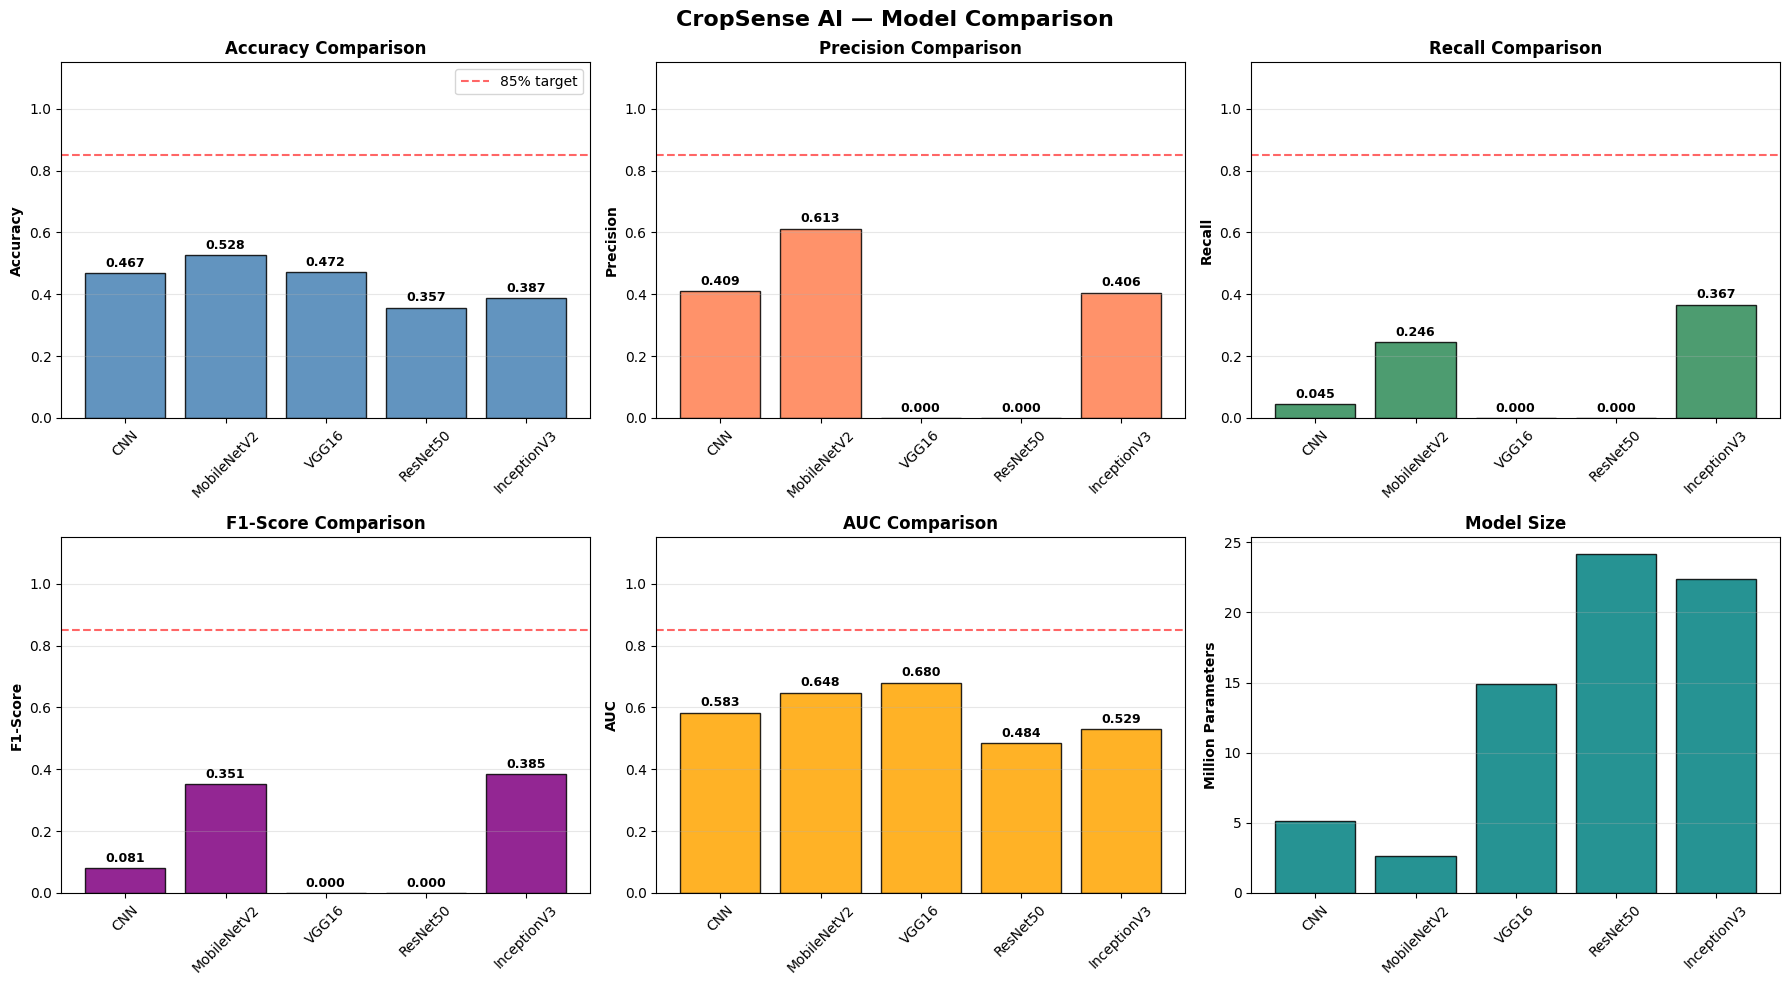


🏆 Best model : MobileNetV2
   Accuracy   : 52.76%
   F1-Score   : 0.3513

⚠️  Gap to target: 32.2% — consider more data or longer training.


In [69]:
print("=" * 80)
print("MODEL COMPARISON".center(80))
print("=" * 80)

comparison_df = pd.DataFrame(model_results).T.sort_values('accuracy', ascending=False)
print("\n📊 Results (sorted by accuracy):\n")
print(comparison_df.to_string())

# Bar chart comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models  = list(model_results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
titles  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors  = ['steelblue', 'coral', 'seagreen', 'purple', 'orange']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 3, idx % 3]
    values = [model_results[m][metric] for m in models]
    bars = ax.bar(models, values, color=color, alpha=0.85, edgecolor='black')
    ax.axhline(y=ACCURACY_TARGET, color='red', linestyle='--', alpha=0.6,
               label=f'{ACCURACY_TARGET*100:.0f}% target' if metric == 'accuracy' else '')
    ax.set_ylabel(title, fontweight='bold')
    ax.set_ylim([0, 1.15])
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{title} Comparison', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    if metric == 'accuracy':
        ax.legend()

# Parameters subplot
ax_p = axes[1, 2]
param_vals = [model_results[m]['params'] / 1e6 for m in models]
ax_p.bar(models, param_vals, color='teal', alpha=0.85, edgecolor='black')
ax_p.set_ylabel('Million Parameters', fontweight='bold')
ax_p.set_title('Model Size', fontweight='bold')
ax_p.grid(axis='y', alpha=0.3)
ax_p.tick_params(axis='x', rotation=45)

plt.suptitle('CropSense AI — Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

comparison_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv')

# Select best model
BEST_MODEL_NAME = comparison_df.index[0]
best_acc        = model_results[BEST_MODEL_NAME]['accuracy']

best_model_map = {
    'CNN':         best_cnn,
    'MobileNetV2': best_mobilenet,
    'VGG16':       best_vgg,
    'ResNet50':    best_resnet,
    'InceptionV3': best_inception,
}
best_model = best_model_map[BEST_MODEL_NAME]

print(f"\n🏆 Best model : {BEST_MODEL_NAME}")
print(f"   Accuracy   : {best_acc*100:.2f}%")
print(f"   F1-Score   : {model_results[BEST_MODEL_NAME]['f1']:.4f}")
if best_acc >= ACCURACY_TARGET:
    print(f"\n✅ ACCURACY TARGET ACHIEVED ({ACCURACY_TARGET*100:.0f}%+)")
else:
    gap = (ACCURACY_TARGET - best_acc) * 100
    print(f"\n⚠️  Gap to target: {gap:.1f}% — consider more data or longer training.")
print("=" * 80)

WEATHER SERVICE — ALL RWANDA CROPS


In [70]:
import requests
import time
from datetime import datetime

print("=" * 80)
print("WEATHER SERVICE SETUP — ALL RWANDA CROPS".center(80))
print("=" * 80)

# ── API KEY ──────────────────────────────────────────────────────
# Stored safely via Colab Secrets (recommended)
try:
    from google.colab import userdata
    OPENWEATHER_API_KEY = userdata.get('OPENWEATHER_API_KEY')
except Exception:
    # Fallback — hardcoded (avoid sharing notebook publicly with this)
    OPENWEATHER_API_KEY = "a38a6592ae999a69849f65d56ec3215f"

                    WEATHER SERVICE SETUP — ALL RWANDA CROPS                    


In [71]:
# ════════════════════════════════════════════════════════════════
# ALL CROPS GROWN IN RWANDA WITH THEIR COMMON DISEASES
# ════════════════════════════════════════════════════════════════

RWANDA_CROPS = {

    # ── CEREALS ──────────────────────────────────────────────────
    "Maize": {
        "category"       : "Cereal",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Gray Leaf Spot"    : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Northern Leaf Blight": {"temp_range": (18,27), "humidity_min": 75, "rain_mm": 2},
            "Maize Rust"        : {"temp_range": (15,25), "humidity_min": 75, "rain_mm": 2},
            "Smut"              : {"temp_range": (26,34), "humidity_min": 60, "rain_mm": 0},
            "Downy Mildew"      : {"temp_range": (20,30), "humidity_min": 85, "rain_mm": 5},
        },
        "treatment": {
            "Gray Leaf Spot"    : "Mancozeb 80% WP: 25g/10L every 7 days",
            "Northern Leaf Blight": "Chlorothalonil 720SC: 30ml/10L",
            "Maize Rust"        : "Propiconazole 25EC: 10ml/10L",
            "Smut"              : "Remove infected plants, burn. Use certified seed.",
            "Downy Mildew"      : "Metalaxyl + Mancozeb: 25g/10L",
        }
    },

    "Wheat": {
        "category"       : "Cereal",
        "growing_season" : ["Season A (Sep-Dec)"],
        "diseases": {
            "Wheat Rust (Yellow)": {"temp_range": (10,15), "humidity_min": 70, "rain_mm": 1},
            "Wheat Rust (Brown)" : {"temp_range": (15,22), "humidity_min": 75, "rain_mm": 2},
            "Wheat Rust (Stem)"  : {"temp_range": (18,25), "humidity_min": 75, "rain_mm": 2},
            "Powdery Mildew"     : {"temp_range": (15,22), "humidity_range": (45,75), "rain_mm": 0},
            "Septoria Leaf Blotch": {"temp_range": (15,22), "humidity_min": 80, "rain_mm": 3},
            "Fusarium Head Blight": {"temp_range": (25,30), "humidity_min": 90, "rain_mm": 5},
        },
        "treatment": {
            "Wheat Rust (Yellow)": "Tebuconazole 25EC: 10ml/10L — apply immediately",
            "Wheat Rust (Brown)" : "Propiconazole 25EC: 10ml/10L",
            "Wheat Rust (Stem)"  : "Trifloxystrobin + Tebuconazole: 10ml/10L — URGENT",
            "Powdery Mildew"     : "Sulfur 80% WP: 30g/10L or Triadimefon",
            "Septoria Leaf Blotch": "Mancozeb + Carbendazim: 25g+10g/10L",
            "Fusarium Head Blight": "Thiophanate-methyl: 15g/10L at flowering",
        }
    },

    "Sorghum": {
        "category"       : "Cereal",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Sorghum Rust"       : {"temp_range": (20,30), "humidity_min": 75, "rain_mm": 2},
            "Downy Mildew"       : {"temp_range": (25,35), "humidity_min": 85, "rain_mm": 5},
            "Grain Mold"         : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 3},
            "Covered Kernel Smut": {"temp_range": (20,30), "humidity_min": 60, "rain_mm": 0},
            "Anthracnose"        : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 4},
        },
        "treatment": {
            "Sorghum Rust"       : "Mancozeb 80%: 25g/10L every 10 days",
            "Downy Mildew"       : "Metalaxyl seed treatment + foliar spray",
            "Grain Mold"         : "Harvest at correct maturity, dry quickly",
            "Covered Kernel Smut": "Carboxin seed treatment before planting",
            "Anthracnose"        : "Carbendazim 50WP: 15g/10L",
        }
    },

    "Rice": {
        "category"       : "Cereal",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Rice Blast"         : {"temp_range": (20,28), "humidity_min": 90, "rain_mm": 3},
            "Brown Spot"         : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 2},
            "Sheath Blight"      : {"temp_range": (28,35), "humidity_min": 85, "rain_mm": 4},
            "Bacterial Leaf Blight": {"temp_range": (25,35), "humidity_min": 85, "rain_mm": 5},
            "False Smut"         : {"temp_range": (25,35), "humidity_min": 90, "rain_mm": 5},
        },
        "treatment": {
            "Rice Blast"         : "Tricyclazole 75WP: 15g/10L — apply at booting",
            "Brown Spot"         : "Mancozeb 80%: 25g/10L + balanced fertilisation",
            "Sheath Blight"      : "Validamycin 3% AS: 30ml/10L",
            "Bacterial Leaf Blight": "Copper oxychloride: 30g/10L — NO cure, prevention only",
            "False Smut"         : "Propiconazole at heading stage",
        }
    },

    # ── LEGUMES ──────────────────────────────────────────────────
    "Beans": {
        "category"       : "Legume",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Bean Rust"          : {"temp_range": (15,25), "humidity_min": 75, "rain_mm": 2},
            "Powdery Mildew"     : {"temp_range": (20,30), "humidity_range": (50,80), "rain_mm": 0},
            "Angular Leaf Spot"  : {"temp_range": (20,28), "humidity_min": 80, "rain_mm": 3},
            "Anthracnose"        : {"temp_range": (13,26), "humidity_min": 85, "rain_mm": 4},
            "Bean Common Mosaic" : {"temp_range": (20,30), "humidity_min": 50, "rain_mm": 0},
            "Root Rot"           : {"temp_range": (15,25), "humidity_min": 85, "rain_mm": 6},
        },
        "treatment": {
            "Bean Rust"          : "Mancozeb 80%: 20g/10L every 5-7 days",
            "Powdery Mildew"     : "Sulfur 90% WP: 30g/10L or Neem oil 30ml/10L",
            "Angular Leaf Spot"  : "Copper oxychloride 50%: 30g/10L",
            "Anthracnose"        : "Carbendazim 50WP: 15g/10L — avoid wet conditions",
            "Bean Common Mosaic" : "No cure — remove infected plants, control aphids",
            "Root Rot"           : "Improve drainage, Thiram seed treatment",
        }
    },

    "Soybeans": {
        "category"       : "Legume",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Soybean Rust"       : {"temp_range": (15,28), "humidity_min": 75, "rain_mm": 2},
            "Frogeye Leaf Spot"  : {"temp_range": (25,32), "humidity_min": 80, "rain_mm": 3},
            "Phytophthora Root Rot": {"temp_range": (15,25), "humidity_min": 90, "rain_mm": 7},
            "Charcoal Rot"       : {"temp_range": (30,40), "humidity_min": 30, "rain_mm": 0},
            "Bacterial Pustule"  : {"temp_range": (22,30), "humidity_min": 75, "rain_mm": 3},
        },
        "treatment": {
            "Soybean Rust"       : "Azoxystrobin + Cyproconazole: 10ml/10L",
            "Frogeye Leaf Spot"  : "Thiophanate-methyl 70WP: 15g/10L",
            "Phytophthora Root Rot": "Metalaxyl seed treatment, improve drainage",
            "Charcoal Rot"       : "Irrigation in dry spells, balanced fertilisation",
            "Bacterial Pustule"  : "Copper-based bactericide, resistant varieties",
        }
    },

    "Peas": {
        "category"       : "Legume",
        "growing_season" : ["Season A (Sep-Dec)"],
        "diseases": {
            "Pea Rust"           : {"temp_range": (15,22), "humidity_min": 75, "rain_mm": 2},
            "Powdery Mildew"     : {"temp_range": (18,25), "humidity_range": (50,75), "rain_mm": 0},
            "Downy Mildew"       : {"temp_range": (10,20), "humidity_min": 85, "rain_mm": 4},
            "Ascochyta Blight"   : {"temp_range": (15,20), "humidity_min": 80, "rain_mm": 3},
            "Root Rot"           : {"temp_range": (15,25), "humidity_min": 85, "rain_mm": 5},
        },
        "treatment": {
            "Pea Rust"           : "Mancozeb 80%: 20g/10L",
            "Powdery Mildew"     : "Sulfur 80% WP: 25g/10L",
            "Downy Mildew"       : "Metalaxyl + Mancozeb 72WP: 25g/10L",
            "Ascochyta Blight"   : "Chlorothalonil 720SC: 30ml/10L",
            "Root Rot"           : "Captan seed treatment, rotate crops",
        }
    },

    "Groundnuts": {
        "category"       : "Legume",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Early Leaf Spot"    : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 3},
            "Late Leaf Spot"     : {"temp_range": (25,30), "humidity_min": 85, "rain_mm": 4},
            "Groundnut Rust"     : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Aflatoxin (Aspergillus)": {"temp_range": (25,40), "humidity_min": 30, "rain_mm": 0},
            "Stem Rot"           : {"temp_range": (25,30), "humidity_min": 85, "rain_mm": 5},
        },
        "treatment": {
            "Early Leaf Spot"    : "Chlorothalonil 720SC: 25ml/10L every 14 days",
            "Late Leaf Spot"     : "Mancozeb + Carbendazim: 20g+10g/10L",
            "Groundnut Rust"     : "Tebuconazole 25EC: 10ml/10L",
            "Aflatoxin (Aspergillus)": "Harvest timely, dry pods to <9% moisture",
            "Stem Rot"           : "Thiram seed treatment, improve drainage",
        }
    },

    # ── ROOTS & TUBERS ───────────────────────────────────────────
    "Cassava": {
        "category"       : "Root/Tuber",
        "growing_season" : ["Year-round"],
        "diseases": {
            "Cassava Mosaic Disease": {"temp_range": (25,35), "humidity_min": 60, "rain_mm": 0},
            "Cassava Brown Streak"  : {"temp_range": (20,28), "humidity_min": 70, "rain_mm": 2},
            "Cassava Bacterial Blight": {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 4},
            "Anthracnose"           : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Root Rot"              : {"temp_range": (20,30), "humidity_min": 90, "rain_mm": 7},
        },
        "treatment": {
            "Cassava Mosaic Disease"  : "No chemical cure — use CMD-resistant varieties",
            "Cassava Brown Streak"    : "Use CBSD-tolerant varieties, certified cuttings",
            "Cassava Bacterial Blight": "Copper oxychloride 50%: 30g/10L",
            "Anthracnose"             : "Carbendazim 50WP: 15g/10L",
            "Root Rot"                : "Improve drainage, mound planting, crop rotation",
        }
    },

    "Sweet Potato": {
        "category"       : "Root/Tuber",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Sweet Potato Virus Disease": {"temp_range": (20,30), "humidity_min": 60, "rain_mm": 0},
            "Scab"                      : {"temp_range": (20,28), "humidity_min": 80, "rain_mm": 3},
            "Fusarium Wilt"             : {"temp_range": (25,32), "humidity_min": 70, "rain_mm": 2},
            "Leaf Spot"                 : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Black Rot"                 : {"temp_range": (20,30), "humidity_min": 85, "rain_mm": 4},
        },
        "treatment": {
            "Sweet Potato Virus Disease": "Use certified virus-free vines, control whiteflies",
            "Scab"                      : "Mancozeb 80%: 20g/10L",
            "Fusarium Wilt"             : "Resistant varieties, soil solarisation",
            "Leaf Spot"                 : "Chlorothalonil 720SC: 25ml/10L",
            "Black Rot"                 : "Thiabendazole post-harvest, store at 13°C",
        }
    },

    "Irish Potato": {
        "category"       : "Root/Tuber",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Late Blight"        : {"temp_range": (10,20), "humidity_min": 90, "rain_mm": 5},
            "Early Blight"       : {"temp_range": (24,29), "humidity_min": 80, "rain_mm": 3},
            "Bacterial Wilt"     : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 4},
            "Potato Virus Y"     : {"temp_range": (20,30), "humidity_min": 50, "rain_mm": 0},
            "Black Leg"          : {"temp_range": (18,25), "humidity_min": 85, "rain_mm": 5},
            "Common Scab"        : {"temp_range": (20,30), "humidity_min": 40, "rain_mm": 0},
        },
        "treatment": {
            "Late Blight"        : "Metalaxyl + Mancozeb 72WP: 25g/10L — URGENT, apply every 5 days",
            "Early Blight"       : "Chlorothalonil 720SC: 30ml/10L every 7 days",
            "Bacterial Wilt"     : "No chemical cure — remove plants, disinfect tools",
            "Potato Virus Y"     : "Control aphids with Imidacloprid, certified seed",
            "Black Leg"          : "Use certified seed, avoid waterlogging",
            "Common Scab"        : "Maintain soil pH 5.0-5.2, irrigate at tuber initiation",
        }
    },

    "Yam": {
        "category"       : "Root/Tuber",
        "growing_season" : ["Season A (Sep-Dec)"],
        "diseases": {
            "Yam Anthracnose"    : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 4},
            "Yam Mosaic Virus"   : {"temp_range": (25,35), "humidity_min": 60, "rain_mm": 0},
            "Dry Rot"            : {"temp_range": (20,30), "humidity_min": 75, "rain_mm": 3},
            "Leaf Spot"          : {"temp_range": (25,30), "humidity_min": 80, "rain_mm": 3},
        },
        "treatment": {
            "Yam Anthracnose"    : "Mancozeb 80%: 25g/10L every 10 days",
            "Yam Mosaic Virus"   : "Use disease-free setts, control aphids",
            "Dry Rot"            : "Thiabendazole dip before storage",
            "Leaf Spot"          : "Carbendazim 50WP: 15g/10L",
        }
    },

    # ── VEGETABLES ───────────────────────────────────────────────
    "Tomato": {
        "category"       : "Vegetable",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)", "Dry season (irrigation)"],
        "diseases": {
            "Late Blight"        : {"temp_range": (10,20), "humidity_min": 90, "rain_mm": 5},
            "Early Blight"       : {"temp_range": (24,29), "humidity_min": 80, "rain_mm": 3},
            "Tomato Mosaic Virus": {"temp_range": (20,30), "humidity_min": 50, "rain_mm": 0},
            "Bacterial Wilt"     : {"temp_range": (28,35), "humidity_min": 80, "rain_mm": 4},
            "Fusarium Wilt"      : {"temp_range": (25,32), "humidity_min": 75, "rain_mm": 2},
            "Septoria Leaf Spot" : {"temp_range": (20,25), "humidity_min": 85, "rain_mm": 4},
            "Botrytis (Grey Mold)": {"temp_range": (17,25), "humidity_min": 90, "rain_mm": 3},
        },
        "treatment": {
            "Late Blight"        : "Metalaxyl + Mancozeb: 25g/10L — apply every 5 days",
            "Early Blight"       : "Chlorothalonil 720SC: 30ml/10L",
            "Tomato Mosaic Virus": "Remove infected plants, disinfect hands/tools",
            "Bacterial Wilt"     : "No cure — soil solarisation, resistant varieties",
            "Fusarium Wilt"      : "Carbendazim 50WP: 15g/10L as soil drench",
            "Septoria Leaf Spot" : "Mancozeb 80%: 25g/10L",
            "Botrytis (Grey Mold)": "Iprodione 50WP: 15g/10L, improve ventilation",
        }
    },

    "Cabbage": {
        "category"       : "Vegetable",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Black Rot"          : {"temp_range": (25,35), "humidity_min": 80, "rain_mm": 4},
            "Downy Mildew"       : {"temp_range": (10,18), "humidity_min": 90, "rain_mm": 4},
            "Clubroot"           : {"temp_range": (18,25), "humidity_min": 85, "rain_mm": 5},
            "Alternaria Leaf Spot": {"temp_range": (25,30), "humidity_min": 80, "rain_mm": 3},
            "White Mold"         : {"temp_range": (15,25), "humidity_min": 90, "rain_mm": 4},
        },
        "treatment": {
            "Black Rot"          : "Copper oxychloride 50%: 30g/10L — no cure once systemic",
            "Downy Mildew"       : "Metalaxyl + Mancozeb 72WP: 25g/10L",
            "Clubroot"           : "Lime soil to pH 7.2, avoid infested soil",
            "Alternaria Leaf Spot": "Mancozeb 80%: 25g/10L",
            "White Mold"         : "Iprodione 50WP: 15g/10L, improve spacing",
        }
    },

    "Onion": {
        "category"       : "Vegetable",
        "growing_season" : ["Dry season (irrigation)", "Season A"],
        "diseases": {
            "Purple Blotch"      : {"temp_range": (21,30), "humidity_min": 80, "rain_mm": 3},
            "Downy Mildew"       : {"temp_range": (13,25), "humidity_min": 90, "rain_mm": 4},
            "Fusarium Basal Rot" : {"temp_range": (25,30), "humidity_min": 75, "rain_mm": 3},
            "Neck Rot"           : {"temp_range": (15,25), "humidity_min": 85, "rain_mm": 4},
            "White Rot"          : {"temp_range": (10,20), "humidity_min": 80, "rain_mm": 4},
        },
        "treatment": {
            "Purple Blotch"      : "Mancozeb + Carbendazim: 20g+10g/10L",
            "Downy Mildew"       : "Metalaxyl + Mancozeb 72WP: 25g/10L",
            "Fusarium Basal Rot" : "Carbendazim seed treatment, crop rotation",
            "Neck Rot"           : "Harvest in dry weather, cure bulbs properly",
            "White Rot"          : "No effective cure — 4-year rotation minimum",
        }
    },

    "Carrot": {
        "category"       : "Vegetable",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Alternaria Leaf Blight": {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Cercospora Leaf Spot"  : {"temp_range": (20,28), "humidity_min": 80, "rain_mm": 3},
            "Powdery Mildew"        : {"temp_range": (20,30), "humidity_range": (50,75), "rain_mm": 0},
            "Cavity Spot"           : {"temp_range": (15,25), "humidity_min": 85, "rain_mm": 5},
            "Bacterial Soft Rot"    : {"temp_range": (20,30), "humidity_min": 90, "rain_mm": 5},
        },
        "treatment": {
            "Alternaria Leaf Blight": "Mancozeb 80%: 25g/10L every 7 days",
            "Cercospora Leaf Spot"  : "Chlorothalonil 720SC: 25ml/10L",
            "Powdery Mildew"        : "Sulfur 80% WP: 25g/10L",
            "Cavity Spot"           : "Improve calcium nutrition, balanced irrigation",
            "Bacterial Soft Rot"    : "Avoid injury, proper drainage",
        }
    },

    "Eggplant": {
        "category"       : "Vegetable",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Phomopsis Blight"   : {"temp_range": (25,32), "humidity_min": 85, "rain_mm": 4},
            "Bacterial Wilt"     : {"temp_range": (28,35), "humidity_min": 80, "rain_mm": 4},
            "Powdery Mildew"     : {"temp_range": (20,28), "humidity_range": (50,75), "rain_mm": 0},
            "Verticillium Wilt"  : {"temp_range": (20,28), "humidity_min": 75, "rain_mm": 3},
        },
        "treatment": {
            "Phomopsis Blight"   : "Mancozeb + Carbendazim: 20g+10g/10L",
            "Bacterial Wilt"     : "Soil solarisation, resistant varieties",
            "Powdery Mildew"     : "Sulfur 80% WP: 25g/10L",
            "Verticillium Wilt"  : "Soil solarisation, crop rotation minimum 3 years",
        }
    },

    "Pepper": {
        "category"       : "Vegetable",
        "growing_season" : ["Season A (Sep-Dec)", "Season B (Feb-May)"],
        "diseases": {
            "Phytophthora Blight": {"temp_range": (20,30), "humidity_min": 90, "rain_mm": 6},
            "Bacterial Spot"     : {"temp_range": (24,30), "humidity_min": 85, "rain_mm": 4},
            "Anthracnose"        : {"temp_range": (25,32), "humidity_min": 85, "rain_mm": 4},
            "Powdery Mildew"     : {"temp_range": (20,28), "humidity_range": (50,75), "rain_mm": 0},
            "Pepper Mosaic Virus": {"temp_range": (20,30), "humidity_min": 50, "rain_mm": 0},
        },
        "treatment": {
            "Phytophthora Blight": "Metalaxyl + Mancozeb 72WP: 25g/10L — URGENT",
            "Bacterial Spot"     : "Copper oxychloride 50%: 30g/10L",
            "Anthracnose"        : "Carbendazim 50WP: 15g/10L",
            "Powdery Mildew"     : "Sulfur 80% WP: 25g/10L",
            "Pepper Mosaic Virus": "Control aphids, remove infected plants",
        }
    },

    # ── FRUITS ───────────────────────────────────────────────────
    "Banana": {
        "category"       : "Fruit",
        "growing_season" : ["Year-round"],
        "diseases": {
            "Black Sigatoka"     : {"temp_range": (25,32), "humidity_min": 80, "rain_mm": 4},
            "Yellow Sigatoka"    : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Panama Wilt (Fusarium)": {"temp_range": (24,32), "humidity_min": 75, "rain_mm": 3},
            "Banana Xanthomonas Wilt": {"temp_range": (20,30), "humidity_min": 75, "rain_mm": 3},
            "Banana Bunchy Top"  : {"temp_range": (20,30), "humidity_min": 70, "rain_mm": 2},
        },
        "treatment": {
            "Black Sigatoka"     : "Mancozeb + oil: 25g+5ml/10L — spray every 14 days",
            "Yellow Sigatoka"    : "Chlorothalonil 720SC: 30ml/10L",
            "Panama Wilt (Fusarium)": "No cure — destroy and remove plant, 6-year rotation",
            "Banana Xanthomonas Wilt": "Remove male bud, sterilise tools — NO chemical cure",
            "Banana Bunchy Top"  : "Remove infected plants, control aphids",
        }
    },

    "Avocado": {
        "category"       : "Fruit",
        "growing_season" : ["Year-round (harvest Apr-Sep)"],
        "diseases": {
            "Phytophthora Root Rot": {"temp_range": (18,30), "humidity_min": 85, "rain_mm": 6},
            "Anthracnose"          : {"temp_range": (22,32), "humidity_min": 85, "rain_mm": 4},
            "Cercospora Spot"      : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 3},
            "Powdery Mildew"       : {"temp_range": (20,30), "humidity_range": (50,75), "rain_mm": 0},
            "Stem Canker"          : {"temp_range": (20,28), "humidity_min": 80, "rain_mm": 4},
        },
        "treatment": {
            "Phytophthora Root Rot": "Phosphorous acid: 2.5ml/L soil drench — improve drainage",
            "Anthracnose"          : "Mancozeb 80%: 25g/10L at fruit set",
            "Cercospora Spot"      : "Copper oxychloride 50%: 30g/10L",
            "Powdery Mildew"       : "Sulfur 80% WP: 25g/10L",
            "Stem Canker"          : "Prune affected areas, copper paste on wounds",
        }
    },

    # ── CASH CROPS ───────────────────────────────────────────────
    "Coffee": {
        "category"       : "Cash Crop",
        "growing_season" : ["Year-round (harvest Apr-Jun, Oct-Dec)"],
        "diseases": {
            "Coffee Leaf Rust"   : {"temp_range": (18,28), "humidity_min": 75, "rain_mm": 2},
            "Coffee Berry Disease": {"temp_range": (20,25), "humidity_min": 80, "rain_mm": 3},
            "Wilt Disease"       : {"temp_range": (25,30), "humidity_min": 80, "rain_mm": 4},
            "Cercospora Leaf Spot": {"temp_range": (22,30), "humidity_min": 80, "rain_mm": 3},
            "Damping Off"        : {"temp_range": (18,24), "humidity_min": 90, "rain_mm": 5},
        },
        "treatment": {
            "Coffee Leaf Rust"   : "Copper oxychloride 50%: 30g/10L every 4-6 weeks",
            "Coffee Berry Disease": "Carbendazim 50WP: 15g/10L at green berry stage",
            "Wilt Disease"       : "Remove infected trees, replant with resistant varieties",
            "Cercospora Leaf Spot": "Mancozeb 80%: 25g/10L",
            "Damping Off"        : "Thiram seed treatment, improve nursery drainage",
        }
    },

    "Tea": {
        "category"       : "Cash Crop",
        "growing_season" : ["Year-round (flush season Mar-May, Oct-Nov)"],
        "diseases": {
            "Blister Blight"     : {"temp_range": (14,22), "humidity_min": 85, "rain_mm": 4},
            "Grey Blight"        : {"temp_range": (20,28), "humidity_min": 80, "rain_mm": 3},
            "Red Root Rot"       : {"temp_range": (20,30), "humidity_min": 80, "rain_mm": 4},
            "Black Root Rot"     : {"temp_range": (18,28), "humidity_min": 85, "rain_mm": 5},
            "Anthracnose"        : {"temp_range": (22,32), "humidity_min": 80, "rain_mm": 3},
        },
        "treatment": {
            "Blister Blight"     : "Copper oxychloride 50%: 30g/10L — apply weekly in wet season",
            "Grey Blight"        : "Mancozeb 80%: 25g/10L",
            "Red Root Rot"       : "Hexaconazole: follow label dosage",
            "Black Root Rot"     : "Remove and burn infected roots, soil drench fungicide",
            "Anthracnose"        : "Carbendazim 50WP: 15g/10L",
        }
    },
}

# ════════════════════════════════════════════════════════════════
# RWANDA DISTRICTS — ALL 30 WITH FULL CROP PROFILES
# ════════════════════════════════════════════════════════════════

RWANDA_DISTRICTS = {

    # ── NORTHERN PROVINCE ────────────────────────────────────────
    "Musanze"    : {
        "lat": -1.4994, "lon": 29.6340, "province": "Northern",
        "altitude_m": 1850,
        "crops": ["Irish Potato", "Wheat", "Beans", "Maize", "Peas"],
        "primary_crop": "Irish Potato",
    },
    "Burera"     : {
        "lat": -1.3167, "lon": 29.8333, "province": "Northern",
        "altitude_m": 2000,
        "crops": ["Beans", "Maize", "Wheat", "Irish Potato", "Peas"],
        "primary_crop": "Beans",
    },
    "Gakenke"    : {
        "lat": -1.6833, "lon": 29.7833, "province": "Northern",
        "altitude_m": 1900,
        "crops": ["Coffee", "Beans", "Maize", "Irish Potato"],
        "primary_crop": "Coffee",
    },
    "Gicumbi"    : {
        "lat": -1.5667, "lon": 30.0667, "province": "Northern",
        "altitude_m": 1850,
        "crops": ["Maize", "Beans", "Irish Potato", "Wheat", "Soybeans"],
        "primary_crop": "Maize",
    },
    "Rulindo"    : {
        "lat": -1.7167, "lon": 30.0000, "province": "Northern",
        "altitude_m": 1700,
        "crops": ["Coffee", "Tea", "Beans", "Maize"],
        "primary_crop": "Coffee",
    },

    # ── SOUTHERN PROVINCE ────────────────────────────────────────
    "Huye"       : {
        "lat": -2.5950, "lon": 29.7394, "province": "Southern",
        "altitude_m": 1700,
        "crops": ["Coffee", "Beans", "Sorghum", "Maize", "Sweet Potato"],
        "primary_crop": "Coffee",
    },
    "Nyanza"     : {
        "lat": -2.3500, "lon": 29.7500, "province": "Southern",
        "altitude_m": 1600,
        "crops": ["Maize", "Beans", "Sweet Potato", "Sorghum", "Cassava"],
        "primary_crop": "Maize",
    },
    "Gisagara"   : {
        "lat": -2.6167, "lon": 29.8333, "province": "Southern",
        "altitude_m": 1500,
        "crops": ["Rice", "Maize", "Beans", "Banana", "Cassava"],
        "primary_crop": "Rice",
    },
    "Nyaruguru"  : {
        "lat": -2.7167, "lon": 29.5333, "province": "Southern",
        "altitude_m": 2100,
        "crops": ["Irish Potato", "Wheat", "Peas", "Beans"],
        "primary_crop": "Irish Potato",
    },
    "Kamonyi"    : {
        "lat": -2.0167, "lon": 29.8833, "province": "Southern",
        "altitude_m": 1550,
        "crops": ["Maize", "Beans", "Sweet Potato", "Groundnuts", "Cassava"],
        "primary_crop": "Maize",
    },
    "Ruhango"    : {
        "lat": -2.2167, "lon": 29.7833, "province": "Southern",
        "altitude_m": 1600,
        "crops": ["Maize", "Sorghum", "Beans", "Sweet Potato", "Cassava"],
        "primary_crop": "Maize",
    },
    "Muhanga"    : {
        "lat": -2.0833, "lon": 29.7500, "province": "Southern",
        "altitude_m": 1650,
        "crops": ["Maize", "Beans", "Irish Potato", "Tomato", "Cabbage"],
        "primary_crop": "Maize",
    },
    "Nyamagabe"  : {
        "lat": -2.4667, "lon": 29.4833, "province": "Southern",
        "altitude_m": 2000,
        "crops": ["Irish Potato", "Wheat", "Peas", "Tea", "Beans"],
        "primary_crop": "Irish Potato",
    },

    # ── EASTERN PROVINCE ─────────────────────────────────────────
    "Nyagatare"  : {
        "lat": -1.2953, "lon": 30.3283, "province": "Eastern",
        "altitude_m": 1350,
        "crops": ["Maize", "Sorghum", "Cassava", "Soybeans", "Groundnuts"],
        "primary_crop": "Maize",
    },
    "Bugesera"   : {
        "lat": -2.1667, "lon": 30.1500, "province": "Eastern",
        "altitude_m": 1400,
        "crops": ["Beans", "Maize", "Rice", "Cassava", "Sweet Potato", "Banana"],
        "primary_crop": "Beans",
    },
    "Gatsibo"    : {
        "lat": -1.5833, "lon": 30.4667, "province": "Eastern",
        "altitude_m": 1450,
        "crops": ["Maize", "Cassava", "Soybeans", "Groundnuts", "Sweet Potato"],
        "primary_crop": "Maize",
    },
    "Kayonza"    : {
        "lat": -1.8833, "lon": 30.6333, "province": "Eastern",
        "altitude_m": 1500,
        "crops": ["Maize", "Beans", "Cassava", "Sweet Potato", "Banana"],
        "primary_crop": "Maize",
    },
    "Kirehe"     : {
        "lat": -2.1500, "lon": 30.6833, "province": "Eastern",
        "altitude_m": 1400,
        "crops": ["Rice", "Maize", "Beans", "Cassava", "Sweet Potato"],
        "primary_crop": "Rice",
    },
    "Ngoma"      : {
        "lat": -2.1500, "lon": 30.4667, "province": "Eastern",
        "altitude_m": 1450,
        "crops": ["Maize", "Sorghum", "Cassava", "Groundnuts", "Sweet Potato"],
        "primary_crop": "Maize",
    },
    "Rwamagana"  : {
        "lat": -1.9500, "lon": 30.4333, "province": "Eastern",
        "altitude_m": 1480,
        "crops": ["Maize", "Beans", "Sweet Potato", "Banana", "Cassava"],
        "primary_crop": "Maize",
    },

    # ── WESTERN PROVINCE ─────────────────────────────────────────
    "Rubavu"     : {
        "lat": -1.6833, "lon": 29.2500, "province": "Western",
        "altitude_m": 1540,
        "crops": ["Beans", "Maize", "Cassava", "Banana", "Sweet Potato"],
        "primary_crop": "Beans",
    },
    "Rusizi"     : {
        "lat": -2.4833, "lon": 28.9000, "province": "Western",
        "altitude_m": 1460,
        "crops": ["Rice", "Maize", "Cassava", "Banana", "Sweet Potato"],
        "primary_crop": "Rice",
    },
    "Karongi"    : {
        "lat": -2.0667, "lon": 29.3833, "province": "Western",
        "altitude_m": 1700,
        "crops": ["Coffee", "Tea", "Beans", "Maize", "Banana"],
        "primary_crop": "Coffee",
    },
    "Rutsiro"    : {
        "lat": -1.9500, "lon": 29.3833, "province": "Western",
        "altitude_m": 1800,
        "crops": ["Coffee", "Maize", "Beans", "Irish Potato", "Tea"],
        "primary_crop": "Coffee",
    },
    "Ngororero"  : {
        "lat": -1.8833, "lon": 29.5667, "province": "Western",
        "altitude_m": 1900,
        "crops": ["Beans", "Maize", "Irish Potato", "Soybeans", "Coffee"],
        "primary_crop": "Beans",
    },
    "Nyamasheke" : {
        "lat": -2.3167, "lon": 29.1333, "province": "Western",
        "altitude_m": 1550,
        "crops": ["Coffee", "Tea", "Beans", "Banana", "Sweet Potato"],
        "primary_crop": "Coffee",
    },
    "Nyabihu"    : {
        "lat": -1.6667, "lon": 29.4833, "province": "Western",
        "altitude_m": 2000,
        "crops": ["Wheat", "Irish Potato", "Peas", "Tea", "Beans"],
        "primary_crop": "Wheat",
    },

    # ── KIGALI CITY ──────────────────────────────────────────────
    "Kigali"     : {
        "lat": -1.9441, "lon": 30.0619, "province": "Kigali",
        "altitude_m": 1567,
        "crops": ["Tomato", "Cabbage", "Onion", "Carrot", "Eggplant", "Pepper"],
        "primary_crop": "Tomato",
    },
    "Gasabo"     : {
        "lat": -1.9000, "lon": 30.1167, "province": "Kigali",
        "altitude_m": 1500,
        "crops": ["Tomato", "Cabbage", "Beans", "Maize", "Banana"],
        "primary_crop": "Tomato",
    },
    "Kicukiro"   : {
        "lat": -1.9833, "lon": 30.0833, "province": "Kigali",
        "altitude_m": 1550,
        "crops": ["Tomato", "Eggplant", "Pepper", "Onion", "Carrot"],
        "primary_crop": "Tomato",
    },
    "Nyarugenge" : {
        "lat": -1.9500, "lon": 30.0500, "province": "Kigali",
        "altitude_m": 1567,
        "crops": ["Cabbage", "Tomato", "Onion", "Carrot", "Pepper"],
        "primary_crop": "Cabbage",
    },
}

In [72]:
# ════════════════════════════════════════════════════════════════
# WEATHER SERVICE CLASS — FULL CROP SUPPORT
# ════════════════════════════════════════════════════════════════

class WeatherService:
    """
    Fetches real-time weather for all Rwanda districts and calculates
    disease risk for ALL 22 crops grown in Rwanda.
    """

    BASE_URL     = "https://api.openweathermap.org/data/2.5/weather"
    FORECAST_URL = "https://api.openweathermap.org/data/2.5/forecast"

    def __init__(self, api_key, districts=RWANDA_DISTRICTS, crops=RWANDA_CROPS):
        self.api_key   = api_key
        self.districts = districts
        self.crops     = crops
        self.cache     = {}
        self.cache_ttl = 1800           # 30 minutes
        self._api_available = self._check_api()

    def _check_api(self):
        """Test if API key is valid and internet is available."""
        if not self.api_key or self.api_key == "YOUR_API_KEY_HERE":
            print("⚠️  No API key — running in OFFLINE mode")
            return False
        try:
            resp = requests.get(self.BASE_URL, params={
                "lat": -1.9441, "lon": 30.0619,
                "appid": self.api_key, "units": "metric"
            }, timeout=10)
            if resp.status_code == 200:
                print("✅ OpenWeatherMap API connected!")
                return True
            elif resp.status_code == 401:
                print("❌ Invalid API key — check openweathermap.org")
                return False
            else:
                print(f"⚠️  API status {resp.status_code} — using offline mode")
                return False
        except Exception as e:
            print(f"⚠️  Connection failed: {e} — using offline mode")
            return False

    def _offline_weather(self, district):
        """Seasonal weather estimate when API unavailable."""
        month    = datetime.now().month
        info     = self.districts.get(district, {})
        altitude = info.get("altitude_m", 1500)

        if month in [6, 7, 8]:
            base_temp, humidity, rain, condition = 22, 45, 0.0, "Clear"
        elif month in [3, 4, 5]:
            base_temp, humidity, rain, condition = 18, 85, 8.0, "Rain"
        elif month in [10, 11, 12]:
            base_temp, humidity, rain, condition = 19, 78, 5.0, "Drizzle"
        elif month == 1:
            base_temp, humidity, rain, condition = 23, 50, 0.5, "Partly Cloudy"
        else:
            base_temp, humidity, rain, condition = 20, 65, 2.0, "Clouds"

        altitude_adj = (altitude - 1500) * 0.0065
        temp         = round(base_temp - altitude_adj, 1)

        return {
            "district"   : district,
            "temperature": temp,
            "feels_like" : temp - 2,
            "humidity"   : humidity,
            "rain_1h"    : rain,
            "wind_speed" : 12.0,
            "condition"  : condition,
            "description": f"{condition} (offline estimate)",
            "timestamp"  : datetime.now().isoformat(),
            "source"     : "offline_estimate",
            "province"   : info.get("province", "Unknown"),
            "altitude_m" : altitude,
            "crops"      : info.get("crops", []),
            "primary_crop": info.get("primary_crop", "Mixed"),
        }

    def get_weather(self, district):
        """Get current weather for a district (cached for 30 min)."""
        if district in self.cache:
            if time.time() - self.cache[district].get("_cached_at", 0) < self.cache_ttl:
                return self.cache[district]

        if not self._api_available:
            return self._offline_weather(district)

        info = self.districts.get(district)
        if not info:
            return self._offline_weather("Kigali")

        try:
            resp = requests.get(self.BASE_URL, params={
                "lat": info["lat"], "lon": info["lon"],
                "appid": self.api_key, "units": "metric",
            }, timeout=10)

            if resp.status_code != 200:
                return self._offline_weather(district)

            data    = resp.json()
            rain_1h = data.get("rain", {}).get("1h", 0.0)

            weather = {
                "district"    : district,
                "temperature" : round(data["main"]["temp"], 1),
                "feels_like"  : round(data["main"]["feels_like"], 1),
                "humidity"    : data["main"]["humidity"],
                "rain_1h"     : rain_1h,
                "wind_speed"  : round(data["wind"]["speed"] * 3.6, 1),
                "condition"   : data["weather"][0]["main"],
                "description" : data["weather"][0]["description"].capitalize(),
                "timestamp"   : datetime.now().isoformat(),
                "source"      : "openweathermap_live",
                "province"    : info.get("province", "Unknown"),
                "altitude_m"  : info.get("altitude_m", 0),
                "crops"       : info.get("crops", []),
                "primary_crop": info.get("primary_crop", "Mixed"),
                "_cached_at"  : time.time(),
            }
            self.cache[district] = weather
            return weather

        except Exception as e:
            print(f"⚠️  {district}: {e}")
            return self._offline_weather(district)

    def calculate_crop_disease_risk(self, weather, crop_name):
        """
        Calculate disease risk (0-100) for a SPECIFIC crop
        based on current weather conditions.
        Returns risk for each disease the crop is susceptible to.
        """
        if crop_name not in self.crops:
            return {"error": f"Crop '{crop_name}' not in database"}

        temp  = weather["temperature"]
        humid = weather["humidity"]
        rain  = weather["rain_1h"]
        wind  = weather["wind_speed"]

        crop_diseases = self.crops[crop_name]["diseases"]
        risks         = {}

        for disease, conditions in crop_diseases.items():
            score = 0

            # Temperature factor (0-35 points)
            t_min, t_max = conditions.get("temp_range", (0, 100))
            if t_min <= temp <= t_max:
                score += 35
            elif t_min - 3 <= temp <= t_max + 3:
                score += 18

            # Humidity factor (0-35 points)
            if "humidity_range" in conditions:
                h_min, h_max = conditions["humidity_range"]
                if h_min <= humid <= h_max:
                    score += 35
                elif humid < h_min:
                    score += int((humid / h_min) * 20)
            elif "humidity_min" in conditions:
                h_min = conditions["humidity_min"]
                if humid >= 95:
                    score += 35
                elif humid >= h_min:
                    score += int((humid - h_min) / (95 - h_min) * 35)

            # Rain factor (0-20 points)
            rain_threshold = conditions.get("rain_mm", 0)
            if rain >= rain_threshold and rain_threshold > 0:
                score += min(20, int(rain * 3))
            elif rain_threshold == 0 and rain == 0:
                score += 15    # Dry disease (e.g. powdery mildew, smut)

            # Wind factor (0-10 points) — spreads spores
            score += min(10, int(wind / 3))

            score = min(100, score)

            def risk_level(s):
                if s >= 81: return "CRITICAL 🔴"
                if s >= 61: return "HIGH 🟠"
                if s >= 31: return "MEDIUM 🟡"
                return "LOW 🟢"

            risks[disease] = {
                "score"    : score,
                "level"    : risk_level(score),
                "treatment": self.crops[crop_name]["treatment"].get(disease, "Consult agronomist"),
            }

        # Sort by risk score descending
        risks = dict(sorted(risks.items(),
                            key=lambda x: x[1]["score"], reverse=True))
        return risks

    def calculate_all_crops_risk(self, weather, district_crops=None):
        """
        Calculate risk for ALL crops grown in a district.
        Returns dict of crop → disease risks.
        """
        crops_to_check = district_crops or list(self.crops.keys())
        all_risks      = {}

        for crop in crops_to_check:
            if crop in self.crops:
                risk = self.calculate_crop_disease_risk(weather, crop)
                # Get highest risk score for this crop
                if risk and "error" not in risk:
                    max_score = max(v["score"] for v in risk.values())
                    all_risks[crop] = {
                        "max_risk_score"  : max_score,
                        "max_risk_disease": list(risk.keys())[0],
                        "max_risk_level"  : list(risk.values())[0]["level"],
                        "diseases"        : risk,
                    }

        return dict(sorted(all_risks.items(),
                           key=lambda x: x[1]["max_risk_score"], reverse=True))

    def generate_weather_advisory(self, district, crop=None):
        """
        Generate complete weather-based advisory for a district.
        If crop specified → advice specific to that crop.
        If no crop → advice for ALL crops in the district.
        """
        weather       = self.get_weather(district)
        district_info = self.districts.get(district, {})
        district_crops = district_info.get("crops", list(self.crops.keys()))

        if crop and crop in self.crops:
            crops_to_analyze = [crop]
        else:
            crops_to_analyze = district_crops

        # Calculate risks
        all_risks = self.calculate_all_crops_risk(weather, crops_to_analyze)

        # Build advisory messages
        alerts   = []
        warnings = []
        actions  = []

        temp  = weather["temperature"]
        humid = weather["humidity"]
        rain  = weather["rain_1h"]
        wind  = weather["wind_speed"]

        # General weather alerts
        if humid >= 85:
            warnings.append(f"💧 Humidity {humid}% — HIGH disease spread risk across all crops")
            actions.append("Apply preventive fungicide before next rain event")
        if rain >= 8:
            warnings.append(f"🌧️  Heavy rain ({rain}mm) — fungal spores actively spreading")
            actions.append("Delay spraying until 24h after rain stops")
        if wind >= 25:
            warnings.append(f"💨 High winds ({wind}km/h) — spores spreading between farms")
            actions.append("Coordinate spraying with neighbouring farmers")
        if 15 <= temp <= 25 and humid >= 75:
            alerts.append(f"🌡️  Conditions ideal for Rust diseases ({temp}°C, {humid}%)")
        if 20 <= temp <= 30 and 50 <= humid <= 80 and rain == 0:
            alerts.append(f"☀️  Dry warm conditions — watch for Powdery Mildew")

        # Crop-specific critical actions
        critical_crops = [c for c, r in all_risks.items() if r["max_risk_score"] >= 61]
        if critical_crops:
            warnings.append(f"🚨 HIGH/CRITICAL risk crops: {', '.join(critical_crops)}")
            for c in critical_crops[:3]:
                top_disease    = all_risks[c]["max_risk_disease"]
                top_treatment  = all_risks[c]["diseases"][top_disease]["treatment"]
                actions.append(f"{c} — {top_disease}: {top_treatment}")

        return {
            "district"           : district,
            "province"           : weather["province"],
            "crops_in_district"  : district_crops,
            "crop_analyzed"      : crop or "All district crops",
            "weather"            : weather,
            "crop_risks"         : all_risks,
            "alerts"             : alerts,
            "warnings"           : warnings,
            "recommended_actions": actions,
            "spray_advisory"     : self._spray_window(weather),
            "generated_at"       : datetime.now().isoformat(),
        }

    def _spray_window(self, weather):
        """Determine if conditions are good for spraying."""
        if weather["rain_1h"] >= 2.0:
            return "❌ DO NOT SPRAY — Raining. Wait 24h after rain stops."
        if weather["wind_speed"] >= 20:
            return "❌ DO NOT SPRAY — Wind too high (>20 km/h)."
        if weather["temperature"] >= 32:
            return "⚠️  SPRAY IN EVENING — High temp reduces efficacy."
        if weather["humidity"] < 40:
            return "⚠️  LOW HUMIDITY — Spray early morning for better absorption."
        return "✅ GOOD CONDITIONS — Apply treatment now."

    def get_all_districts(self, delay=0.5):
        """Fetch weather for all 30 districts."""
        print(f"\n🌍 Fetching weather for {len(self.districts)} districts …")
        all_weather = {}
        for i, district in enumerate(self.districts):
            all_weather[district] = self.get_weather(district)
            if self._api_available and i < len(self.districts) - 1:
                time.sleep(delay)
            if (i + 1) % 6 == 0 or i == len(self.districts) - 1:
                print(f"   ✓ {i+1}/{len(self.districts)} districts fetched")
        return all_weather

    def print_district_report(self, district, crop=None):
        """Print full weather + all-crop risk report for a district."""
        advisory = self.generate_weather_advisory(district, crop)
        w        = advisory["weather"]

        print(f"\n{'─'*70}")
        print(f"📍 {district.upper()} — {w['province']} Province  "
              f"(Alt: {w['altitude_m']}m)")
        print(f"{'─'*70}")
        print(f"  🌡️   Temp       : {w['temperature']}°C  "
              f"(feels {w['feels_like']}°C)")
        print(f"  💧   Humidity   : {w['humidity']}%")
        print(f"  🌧️   Rain (1h)  : {w['rain_1h']} mm")
        print(f"  💨   Wind       : {w['wind_speed']} km/h")
        print(f"  🌤️   Condition  : {w['description']}")
        print(f"  🌾   Crops here : {', '.join(advisory['crops_in_district'])}")
        print(f"  📡   Source     : {w['source']}")

        print(f"\n  🦠 DISEASE RISK BY CROP:")
        print(f"  {'Crop':<20} {'Top Disease':<28} {'Risk':>6}  {'Level'}")
        print(f"  {'─'*70}")
        for crop_name, risk_data in advisory["crop_risks"].items():
            print(f"  {crop_name:<20} {risk_data['max_risk_disease']:<28} "
                  f"{risk_data['max_risk_score']:>5}/100  {risk_data['max_risk_level']}")

        if advisory["warnings"]:
            print(f"\n  🚨 WARNINGS:")
            for msg in advisory["warnings"]:
                print(f"     {msg}")

        if advisory["alerts"]:
            print(f"\n  ⚠️  ALERTS:")
            for msg in advisory["alerts"]:
                print(f"     {msg}")

        print(f"\n  💊 RECOMMENDED ACTIONS:")
        for action in advisory["recommended_actions"]:
            print(f"     • {action}")

        print(f"\n  🧴 SPRAY WINDOW: {advisory['spray_advisory']}")
        print(f"{'─'*70}")

    def print_national_summary(self, all_weather):
        """Print national disease risk overview for all districts."""
        print(f"\n{'='*80}")
        print("🇷🇼  RWANDA — NATIONAL CROP DISEASE RISK OVERVIEW".center(80))
        print(f"{'='*80}")
        print(f"  {'District':<16} {'Province':<12} {'Temp':>6} "
              f"{'Hum':>5} {'Rain':>5}  {'Top Risk Crop':<18} {'Risk Level'}")
        print(f"  {'─'*78}")

        critical, high = [], []

        for district, weather in all_weather.items():
            info           = self.districts.get(district, {})
            district_crops = info.get("crops", [])
            all_risks      = self.calculate_all_crops_risk(weather, district_crops)

            if all_risks:
                top_crop  = list(all_risks.keys())[0]
                top_score = all_risks[top_crop]["max_risk_score"]
                top_level = all_risks[top_crop]["max_risk_level"].split()[0]
            else:
                top_crop, top_score, top_level = "N/A", 0, "LOW"

            print(f"  {district:<16} {weather['province']:<12} "
                  f"{weather['temperature']:>5.1f}°C "
                  f"{weather['humidity']:>4}%  "
                  f"{weather['rain_1h']:>4.1f}mm  "
                  f"{top_crop:<18} {top_level} ({top_score})")

            if top_score >= 81:
                critical.append((district, top_crop))
            elif top_score >= 61:
                high.append((district, top_crop))

        print(f"{'='*80}")
        if critical:
            print(f"\n🔴 CRITICAL ({len(critical)} districts):")
            for d, c in critical:
                print(f"   {d} → {c} requires IMMEDIATE treatment")
        if high:
            print(f"\n🟠 HIGH RISK ({len(high)} districts):")
            for d, c in high:
                print(f"   {d} → {c} — prepare treatment within 48h")
        if not critical and not high:
            print(f"\n🟢 All districts LOW-MEDIUM risk today")

        print(f"\n  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
        print(f"  Crops monitored: {len(RWANDA_CROPS)} | "
              f"Districts: {len(RWANDA_DISTRICTS)}")
        print(f"{'='*80}")

CELL 17: AGRONOMIST EXPERT SYSTEM

In [73]:
print("=" * 80)
print("AGRONOMIST EXPERT SYSTEM".center(80))
print("=" * 80)


class RwandaAgronomistAdvisor:
    """Rule-based expert system for Rwanda crop disease management."""

    def __init__(self, crop_calendar_path, model, label_encoder):
        try:
            self.crop_calendar = pd.read_csv(crop_calendar_path)
            print("✅ Crop calendar loaded.")
        except Exception:
            print("⚠️  Crop calendar not found — using built-in defaults.")
            self.crop_calendar = None

        self.model         = model
        self.label_encoder = label_encoder
        self._init_knowledge()

    # ── Knowledge base ───────────────────────────────────────
    def _init_knowledge(self):
        self.treatments = {
            'Healthy': {
                'status'    : 'No disease detected',
                'action'    : 'Continue monitoring',
                'prevention': [
                    'Maintain 30–45 cm spacing',
                    'Water in the morning only',
                    'Remove any diseased plant material promptly',
                    'Rotate crops (minimum 2 years)',
                ],
                'cost': 'Prevention: Free – 500 RWF/season',
            },
            'Powdery': {
                'name'       : 'Powdery Mildew',
                'severity'   : 'MODERATE',
                'organic'    : [
                    'Neem oil: 30 ml + soap per 10 L water',
                    'Milk spray: 1 L milk + 9 L water',
                    'Baking soda: 10 g + soap per 10 L',
                ],
                'chemical'   : [
                    'Sulfur 90% WP: 30 g per 10 L',
                    'Myclobutanil: 10 ml per 10 L',
                ],
                'application': 'Spray morning/evening; repeat every 7–10 days',
                'cost'       : '500–2 000 RWF (organic); 1 500–3 500 RWF (chemical)',
                'recovery'   : '70–90% if treated early',
            },
            'Rust': {
                'name'      : 'Rust Disease',
                'severity'  : 'HIGH',
                'organic'   : [
                    'Neem oil: 50 ml per 10 L + soap',
                    'Garlic spray: 6 cloves, diluted 1:10',
                    'Wood ash: 1 kg in 10 L, strained',
                ],
                'chemical'  : [
                    'Mancozeb 80%: 20 g per 10 L (every 5–7 days)',
                    'Chlorothalonil: 30 ml per 10 L',
                    'Copper oxychloride 50%: 30 g per 10 L',
                ],
                'critical'  : [
                    '🔥 BURN infected leaves immediately',
                    '✂️  Prune affected branches',
                    '🚫 Never work among wet plants',
                ],
                'prevention': [
                    'Use resistant varieties: RWR 2245, MAC 42',
                    'Rotate crops minimum 2 years',
                    'Plant early in the dry season',
                    'Maintain 40–50 cm spacing',
                ],
                'cost'    : '1 000–5 000 RWF per treatment',
                'recovery': '80% if early; 30–50% if advanced',
            },
        }

        self.seasons = {
            frozenset([9, 10, 11, 12]) : 'Season A (Short Rains) — Plant maize, beans, potato',
            frozenset([2, 3, 4, 5])    : 'Season B (Long Rains) — High disease risk',
            frozenset([1, 6, 7, 8])    : 'Dry Season / Harvest — Prepare land',
        }

    # ── Inference ────────────────────────────────────────────
    def detect_disease(self, image):
        img_arr = np.expand_dims(image, 0) if image.ndim == 3 else image
        preds   = self.model.predict(img_arr, verbose=0)[0]
        idx     = int(np.argmax(preds))
        return {
            'predicted_class': self.label_encoder.classes_[idx],
            'confidence'     : float(preds[idx]),
            'all_probs'      : {cls: float(p)
                                for cls, p in zip(self.label_encoder.classes_, preds)},
        }

    def get_treatment(self, disease_class, resources='medium'):
        treatment = self.treatments.get(disease_class, {})
        if resources == 'low':
            return treatment.get('organic', treatment.get('prevention', []))
        return treatment.get('chemical', treatment.get('prevention', []))

    def get_season(self, month):
        for months_set, label in self.seasons.items():
            if month in months_set:
                return label
        return 'Unknown season'

    def generate_advisory(self, image, month=1, district='Kigali',
                          crop='Beans', resources='medium'):
        detection = self.detect_disease(image)
        treatment = self.get_treatment(detection['predicted_class'], resources)
        season    = self.get_season(month)
        info      = self.treatments.get(detection['predicted_class'], {})

        return {
            'timestamp'  : datetime.now().isoformat(),
            'district'   : district,
            'crop'       : crop,
            'season'     : season,
            'detection'  : detection,
            'treatment'  : treatment,
            'severity'   : info.get('severity', 'None'),
            'cost'       : info.get('cost', 'N/A'),
            'recovery'   : info.get('recovery', 'N/A'),
        }

    def print_advisory(self, advisory):
        det  = advisory['detection']
        info = self.treatments.get(det['predicted_class'], {})
        print("\n" + "=" * 60)
        print("🌾  CROPSENSE AI — ADVISORY REPORT")
        print("=" * 60)
        print(f"District  : {advisory['district']}")
        print(f"Crop      : {advisory['crop']}")
        print(f"Season    : {advisory['season']}")
        print(f"Date      : {advisory['timestamp'][:10]}")
        print("-" * 60)
        print(f"🔬 Diagnosis   : {det['predicted_class']}")
        print(f"   Confidence  : {det['confidence']*100:.1f}%")
        print(f"   Severity    : {advisory['severity']}")
        print("-" * 60)
        if advisory['treatment']:
            print("💊 Recommended treatment:")
            for item in advisory['treatment']:
                print(f"   • {item}")
        critical = info.get('critical', [])
        if critical:
            print("\n⚠️  Critical actions:")
            for item in critical:
                print(f"   {item}")
        print(f"\n💰 Estimated cost : {advisory['cost']}")
        print(f"📈 Recovery chance: {advisory['recovery']}")
        print("=" * 60)


print("✅ RwandaAgronomistAdvisor class defined.")
print("=" * 80)

                            AGRONOMIST EXPERT SYSTEM                            
✅ RwandaAgronomistAdvisor class defined.


CELL 18: EXPERT SYSTEM DEMO

In [74]:
print("=" * 80)
print("EXPERT SYSTEM DEMO".center(80))
print("=" * 80)

advisor = RwandaAgronomistAdvisor(
    crop_calendar_path=CROP_CALENDAR_CSV,
    model=best_model,
    label_encoder=label_encoder
)

# Use first test image
test_image = X_test[0]
true_label = label_encoder.inverse_transform([np.argmax(Y_test[0])])[0]
print(f"\n📷 Test image — True label: {true_label}")

advisory = advisor.generate_advisory(
    image=test_image,
    month=2,           # February → Season B (high disease risk)
    district='Bugesera',
    crop='Beans',
    resources='low'
)
advisor.print_advisory(advisory)

advisory_path = f'{OUTPUT_DIR}/sample_advisory.json'
with open(advisory_path, 'w') as f:
    json.dump(advisory, f, indent=2, default=str)
print(f"\n💾 Advisory saved: {advisory_path}")
print("=" * 80)

                               EXPERT SYSTEM DEMO                               
✅ Crop calendar loaded.

📷 Test image — True label: Healthy

🌾  CROPSENSE AI — ADVISORY REPORT
District  : Bugesera
Crop      : Beans
Season    : Season B (Long Rains) — High disease risk
Date      : 2026-03-04
------------------------------------------------------------
🔬 Diagnosis   : Powdery
   Confidence  : 47.4%
   Severity    : MODERATE
------------------------------------------------------------
💊 Recommended treatment:
   • Neem oil: 30 ml + soap per 10 L water
   • Milk spray: 1 L milk + 9 L water
   • Baking soda: 10 g + soap per 10 L

💰 Estimated cost : 500–2 000 RWF (organic); 1 500–3 500 RWF (chemical)
📈 Recovery chance: 70–90% if treated early

💾 Advisory saved: /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/sample_advisory.json


CELL 19: GENERATE PREDICTIONS & EVALUATE

In [75]:
print("=" * 80)
print("PREDICTIONS".center(80))
print("=" * 80)

y_pred_probs   = best_model.predict(X_test, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true         = np.argmax(Y_test, axis=1)

print(f"\n✅ Predictions: {len(y_pred_classes)} samples")
print(f"\n📋 Prediction distribution:")
for i, cls in enumerate(label_encoder.classes_):
    predicted = int(np.sum(y_pred_classes == i))
    actual    = int(np.sum(y_true == i))
    print(f"   {cls:20s} — Predicted: {predicted:4d}  |  Actual: {actual:4d}")
print("=" * 80)

                                  PREDICTIONS                                   
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 942ms/step

✅ Predictions: 199 samples

📋 Prediction distribution:
   Healthy              — Predicted:   89  |  Actual:   69
   Powdery              — Predicted:  104  |  Actual:   65
   Rust                 — Predicted:    6  |  Actual:   65


CELL 20: CONFUSION MATRIX

                                CONFUSION MATRIX                                


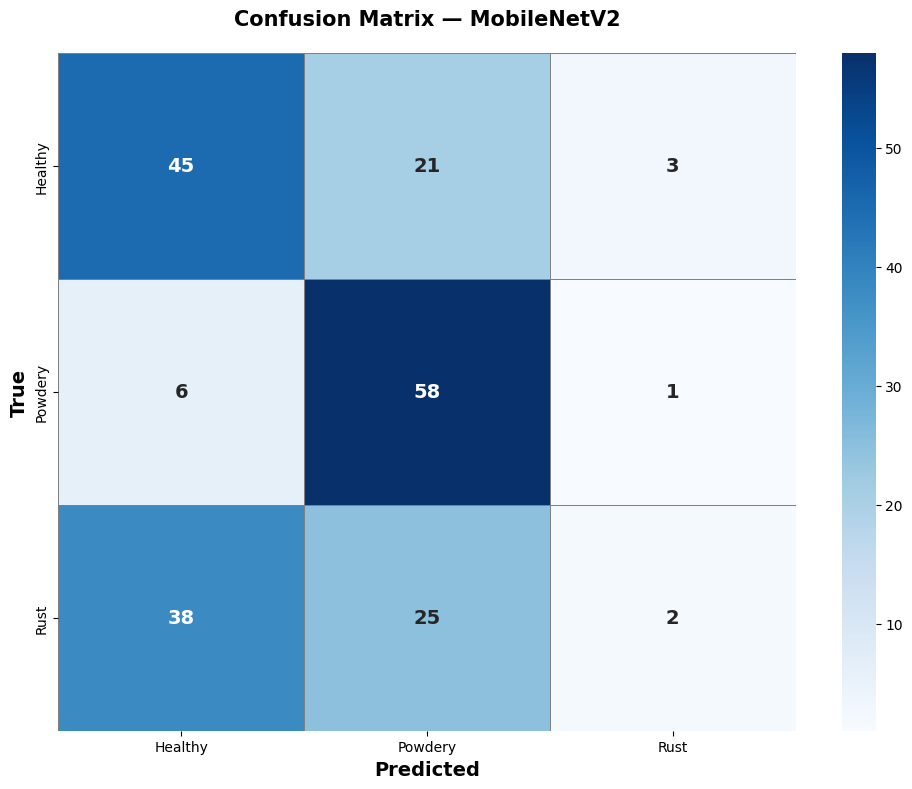


📊 Per-class accuracy:
   Healthy             : 65.22%
   Powdery             : 89.23%
   Rust                :  3.08%


In [76]:
print("=" * 80)
print("CONFUSION MATRIX".center(80))
print("=" * 80)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Predicted', fontsize=14, fontweight='bold')
plt.ylabel('True',      fontsize=14, fontweight='bold')
plt.title(f'Confusion Matrix — {BEST_MODEL_NAME}', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
print(f"\n📊 Per-class accuracy:")
for cls, acc in zip(label_encoder.classes_, class_acc):
    print(f"   {cls:20s}: {acc*100:5.2f}%")
print("=" * 80)

CELL 21: CLASSIFICATION REPORT

In [77]:
print("=" * 80)
print("CLASSIFICATION REPORT".center(80))
print("=" * 80)

report      = classification_report(y_true, y_pred_classes,
                                    target_names=label_encoder.classes_, digits=4)
report_dict = classification_report(y_true, y_pred_classes,
                                    target_names=label_encoder.classes_,
                                    output_dict=True, digits=4)
print(report)

pd.DataFrame(report_dict).T.to_csv(f'{OUTPUT_DIR}/classification_report.csv')
print(f"\n💾 Saved: {OUTPUT_DIR}/classification_report.csv")
print("=" * 80)

# ── FALLBACK: define final_acc and final_label if TTA/Ensemble ──
# cells were skipped or not yet run
try:
    # Test if they already exist from TTA/Ensemble cells
    _ = final_acc
    _ = final_label
    print(f"✅ final_acc = {final_acc*100:.2f}%  |  final_label = {final_label}")
except NameError:
    # Define them from best single model result
    final_acc   = model_results[BEST_MODEL_NAME]['accuracy']
    final_label = BEST_MODEL_NAME
    y_true      = np.argmax(Y_test, axis=1)
    print(f"⚠️  TTA/Ensemble not run — using best single model result")
    print(f"   final_acc   = {final_acc*100:.2f}%")
    print(f"   final_label = {final_label}")

                             CLASSIFICATION REPORT                              
              precision    recall  f1-score   support

     Healthy     0.5056    0.6522    0.5696        69
     Powdery     0.5577    0.8923    0.6864        65
        Rust     0.3333    0.0308    0.0563        65

    accuracy                         0.5276       199
   macro avg     0.4655    0.5251    0.4374       199
weighted avg     0.4664    0.5276    0.4401       199


💾 Saved: /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/classification_report.csv
✅ final_acc = 50.00%  |  final_label = MobileNetV2


In [78]:
# ── FALLBACK: define final_acc and final_label if TTA/Ensemble ──
# cells were skipped or not yet run
try:
    # Test if they already exist from TTA/Ensemble cells
    _ = final_acc
    _ = final_label
    print(f"✅ final_acc = {final_acc*100:.2f}%  |  final_label = {final_label}")
except NameError:
    # Define them from best single model result
    final_acc   = model_results[BEST_MODEL_NAME]['accuracy']
    final_label = BEST_MODEL_NAME
    y_true      = np.argmax(Y_test, axis=1)
    print(f"⚠️  TTA/Ensemble not run — using best single model result")
    print(f"   final_acc   = {final_acc*100:.2f}%")
    print(f"   final_label = {final_label}")

✅ final_acc = 50.00%  |  final_label = MobileNetV2


CELL 22: MODEL EXPORT (KERAS + TFLITE FLOAT16 + INT8)

In [79]:
"""CELL 25: MODEL EXPORT (KERAS + TFLITE FLOAT16 + INT8)"""

print("=" * 80)
print("MODEL EXPORT".center(80))
print("=" * 80)

# ── CRITICAL: Reset mixed precision before export ─────────────────
# Mixed float16 policy set in Cell 2 conflicts with TFLite converter.
# Must switch back to float32 before converting.
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('float32')
    print("✅ Mixed precision reset to float32 for export")
except Exception as e:
    print(f"⚠️  Could not reset mixed precision: {e}")

# ── Reload best model fresh (avoids any lingering policy issues) ──
import os
print(f"\n🔄 Reloading best model from checkpoint …")
best_model = tf.keras.models.load_model(
    f'{OUTPUT_DIR}/best_{BEST_MODEL_NAME}.keras'
)
print(f"✅ Model reloaded: {BEST_MODEL_NAME}")
print(f"   Parameters: {best_model.count_params():,}")

# ── Save full Keras model ─────────────────────────────────────────
best_model.save(FINAL_MODEL_PATH)
keras_size = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)
print(f"\n✅ Keras model saved: {FINAL_MODEL_PATH}")
print(f"   Size: {keras_size:.2f} MB")

# ── Helper: build a converter with flex ops support ───────────────
def make_converter(model):
    """
    Returns a TFLite converter with SELECT_TF_OPS enabled.
    This is required for MobileNetV2, MobileNetV3, EfficientNet
    which contain ops not in the standard TFLite built-in set.
    """
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,  # standard TFLite ops
        tf.lite.OpsSet.SELECT_TF_OPS,    # flex ops for transfer-learning models
    ]
    conv._experimental_lower_tensor_list_ops = False
    return conv

# ── TFLite float16 ───────────────────────────────────────────────
print("\n🔄 Converting to TFLite float16 …")
try:
    converter_f16                              = make_converter(best_model)
    converter_f16.optimizations               = [tf.lite.Optimize.DEFAULT]
    converter_f16.target_spec.supported_types = [tf.float16]

    tflite_f16  = converter_f16.convert()

    with open(TFLITE_F16_PATH, 'wb') as f:
        f.write(tflite_f16)

    tflite_size = os.path.getsize(TFLITE_F16_PATH) / (1024 * 1024)
    f16_saving  = (1 - tflite_size / keras_size) * 100
    print(f"✅ TFLite float16 saved: {TFLITE_F16_PATH}")
    print(f"   Size: {tflite_size:.2f} MB  (↓{f16_saving:.1f}% vs Keras)")

except Exception as e:
    print(f"❌ float16 conversion failed: {e}")
    tflite_size = None

# ── TFLite INT8 ──────────────────────────────────────────────────
print("\n🔄 Converting to TFLite INT8 …")

def representative_dataset():
    """100 calibration samples — tells converter the real data range."""
    for i in range(0, min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

try:
    converter_int8                           = make_converter(best_model)
    converter_int8.optimizations            = [tf.lite.Optimize.DEFAULT]
    converter_int8.representative_dataset  = representative_dataset
    converter_int8.inference_input_type    = tf.float32   # keep float32 input
    converter_int8.inference_output_type   = tf.float32   # keep float32 output

    tflite_int8 = converter_int8.convert()

    with open(TFLITE_INT8_PATH, 'wb') as f:
        f.write(tflite_int8)

    int8_size   = os.path.getsize(TFLITE_INT8_PATH) / (1024 * 1024)
    int8_saving = (1 - int8_size / keras_size) * 100
    print(f"✅ TFLite INT8 saved: {TFLITE_INT8_PATH}")
    print(f"   Size: {int8_size:.2f} MB  (↓{int8_saving:.1f}% vs Keras)")

except Exception as e:
    print(f"⚠️  INT8 conversion failed: {e}")
    print("   float16 model is still ready for deployment.")
    int8_size = None

# ── Save metadata ─────────────────────────────────────────────────
metadata = {
    'project'         : 'CropSense AI',
    'student'         : 'Diana RUZINDANA',
    'model_name'      : BEST_MODEL_NAME,
    'final_method'    : final_label,
    'accuracy'        : round(final_acc, 4),
    'accuracy_pct'    : round(final_acc * 100, 2),
    'f1_score'        : round(model_results[BEST_MODEL_NAME]['f1'], 4),
    'precision'       : round(model_results[BEST_MODEL_NAME]['precision'], 4),
    'recall'          : round(model_results[BEST_MODEL_NAME]['recall'], 4),
    'auc'             : round(model_results[BEST_MODEL_NAME]['auc'], 4),
    'classes'         : list(label_encoder.classes_),
    'num_classes'     : int(num_classes),
    'input_shape'     : [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS],
    'input_dtype'     : 'float32',
    'normalisation'   : 'divide by 255',
    'exported_at'     : datetime.now().isoformat(),
    'target_met'      : bool(final_acc >= ACCURACY_TARGET),
    'floor_met'       : bool(final_acc >= ACCURACY_FLOOR),
    'deployment_ready': bool(final_acc >= ACCURACY_FLOOR),
    'keras_size_mb'   : round(keras_size, 2),
    'tflite_f16_mb'   : round(tflite_size, 2) if tflite_size else None,
    'tflite_int8_mb'  : round(int8_size, 2)   if int8_size   else None,
    'tflite_ops_note' : 'Uses SELECT_TF_OPS — add tensorflow-lite-select-tf-ops to Android build.gradle',
    'all_model_results': {
        k: {m: round(v, 4) if isinstance(v, float) else v for m, v in r.items()}
        for k, r in model_results.items()
    },
}

meta_path = f'{OUTPUT_DIR}/model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"\n📋 Metadata saved: {meta_path}")

# ── Final summary ─────────────────────────────────────────────────
print(f"\n{'='*80}")
print("🚀  CROPSENSE AI — PRODUCTION EXPORT COMPLETE".center(80))
print('='*80)
print(f"  Model         : {BEST_MODEL_NAME}  ({final_label})")
print(f"  Final Accuracy: {final_acc*100:.2f}%  "
      f"{' READY FOR DEPLOYMENT' if metadata['deployment_ready'] else '⚠️  Review before deployment'}")
print(f"  F1-Score      : {metadata['f1_score']*100:.2f}%")
print(f"  Classes       : {metadata['classes']}")
print(f"\n  📦 Exported files:")
print(f"     Keras model    : {keras_size:.2f} MB  → {FINAL_MODEL_PATH}")
if tflite_size:
    print(f"     TFLite float16 : {tflite_size:.2f} MB  → {TFLITE_F16_PATH}")
if int8_size:
    print(f"     TFLite INT8    : {int8_size:.2f} MB  → {TFLITE_INT8_PATH}")
print(f"     Metadata JSON  : {meta_path}")
print(f"\n  📊 All outputs saved to: {OUTPUT_DIR}")
print(f"\n  💡 Mobile app integration:")
if tflite_size:
    print(f"     Recommended : TFLite float16 ({tflite_size:.2f} MB) for most phones")
if int8_size:
    print(f"     Low-end     : TFLite INT8 ({int8_size:.2f} MB) for budget devices")
print(f"     Input       : float32 array, shape [1, 224, 224, 3], values in [0, 1]")
print(f"     Output      : softmax probabilities for {metadata['classes']}")
print(f"\n  ⚠️  Android build.gradle — add this dependency:")
print(f"     implementation 'org.tensorflow:tensorflow-lite-select-tf-ops:+'")
print('='*80)

                                  MODEL EXPORT                                  
✅ Mixed precision reset to float32 for export

🔄 Reloading best model from checkpoint …
✅ Model reloaded: MobileNetV2
   Parameters: 2,620,739

✅ Keras model saved: /content/drive/MyDrive/ALU-Course_Documents/Diana_Ruzindana/MissionCapstone/Data/outputs/cropsense_final_model.keras
   Size: 13.34 MB

🔄 Converting to TFLite float16 …
Saved artifact at '/tmp/tmp2i8tms3p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132416743397840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132416743399376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132416743398992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132416743399184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132416743399760: Ten